# Sparse autoencoder

In [1]:
import torch
from torch import nn
from torch.utils import data
import matplotlib.pyplot as plt
from config import (
    SEED,
    TRAIN_BS,
    VAL_BS,
    COLORED_PROPORTION,
    CLS_EPOCHS,
    RUN_NAME
)
from models import ClsModel, SAE, TopkSAE, BatchTopkSAE, MatryoshkaBatchTopkSAE, TrimmedClsModel
import train_utils
import plot_utils
import metrics
import os
import tqdm
import data_utils
import functools
from typing import List

In [2]:
SAE_FEATURES_LAYER = -2	# Output of this layer will be used as input for the SAE
SAE_INPUT_FEATURES = 16
SAE_EXPANSION_FACTOR = 4
SAE_ALPHA = 4
SAE_TOPK = 2    # Only applies when using TopKSAE
SAE_BS = 128

MATRYOSHKA_SAE = False	# Wheter to use matryoshka SAE
MATRYOSHKA_EXPANSION_FACTORS = [0.25, 2, 4]	# Expansion factors for each nested SAE in MatryoshkaSAE

In [3]:
plt.style.use('default')

device = "cuda" if torch.cuda.is_available() else "mps"

In [4]:
train_dataset = torch.load("./data/train_dataset.pt", weights_only=False)
val_dataset = torch.load("./data/val_dataset.pt", weights_only=False)
clean_val_dataset = torch.load("./data/clean_val_dataset.pt", weights_only=False)
fully_colored_val_dataset = torch.load("./data/fully_colored_val_dataset.pt", weights_only=False)
colors_flipped_val_dataset = torch.load("./data/colors_flipped_val_dataset.pt", weights_only=False)

train_dataloader = data.DataLoader(train_dataset, batch_size=TRAIN_BS, shuffle=True)
val_dataloader = data.DataLoader(val_dataset, batch_size=VAL_BS)
clean_val_dataloader = data.DataLoader(clean_val_dataset, batch_size=VAL_BS)
fully_colored_val_dataloader = data.DataLoader(fully_colored_val_dataset, batch_size=VAL_BS)
colors_flipped_val_dataloader = data.DataLoader(colors_flipped_val_dataset, batch_size=VAL_BS)

In [5]:
model = ClsModel()

model.load_state_dict(torch.load(os.path.join("weights", RUN_NAME, "cls_model.pt")))
model.to(device)

ClsModel(
  (fc): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=2352, out_features=16, bias=True)
    (2): Tanh()
    (3): Linear(in_features=16, out_features=10, bias=True)
  )
)

In [6]:
sae_input_shape = SAE_INPUT_FEATURES

SAE_HIDDEN_DIM = sae_input_shape*SAE_EXPANSION_FACTOR

print(f"Training SAE with hidden dim {SAE_HIDDEN_DIM} and expansion factor {SAE_EXPANSION_FACTOR}")

Training SAE with hidden dim 64 and expansion factor 4


In [7]:
sae_train_dataset = data_utils.generate_sae_dataset(model, train_dataset, layer_idx=SAE_FEATURES_LAYER, device=device, sae_input_shape=SAE_INPUT_FEATURES)
sae_val_dataset = data_utils.generate_sae_dataset(model, val_dataset, layer_idx=SAE_FEATURES_LAYER, device=device, sae_input_shape=SAE_INPUT_FEATURES)

sae_train_dataloader = data.DataLoader(sae_train_dataset, SAE_BS, shuffle=True)
sae_val_dataloader = data.DataLoader(sae_val_dataset, SAE_BS, shuffle=False)

  0%|          | 0/48000 [00:00<?, ?it/s]

100%|██████████| 12000/12000 [00:04<00:00, 2483.09it/s]


In [8]:
def sae_criterion_fn(outputs, targets, hidden, alpha=0.5):
    """
    SAE criterion that applies both L1 loss on hidden SAE vector as well as L2 reconstruction loss.
    
    Args:
		outputs: Output of the SAE decoder.
        targets: Target used for reconstruction loss.
        hidden: Sparse hidden vector, output of the SAE's encoder.
        alpha (optional): Weight applied to sparsity loss.
    Returns:
		torch.Tensor: Combined sparsity and reconstruction loss.
    """
    mae = torch.mean(torch.abs(hidden))	# L1 Loss to ensure hidden layer sparsity
    reconstruction_loss = torch.mean((outputs-targets)**2)
    return reconstruction_loss+alpha*mae

In [9]:
torch.manual_seed(SEED)	# Set random seed for weights reproducibility

if MATRYOSHKA_SAE:
	sae_model = MatryoshkaBatchTopkSAE(sae_input_shape, MATRYOSHKA_EXPANSION_FACTORS, SAE_TOPK)
	sae_criterion = nn.MSELoss()
else:
	if SAE_TOPK > 0:
		sae_model = BatchTopkSAE(sae_input_shape, SAE_HIDDEN_DIM, topk=SAE_TOPK)
		sae_criterion = nn.MSELoss()
	else:
		sae_model = SAE(sae_input_shape, SAE_HIDDEN_DIM)
		sae_criterion = functools.partial(sae_criterion_fn, alpha=SAE_ALPHA)

sae_model.to(device)
sae_optimizer = torch.optim.AdamW(sae_model.parameters(), lr=1e-3)


In [10]:
train_losses, val_losses = train_utils.sae_train(sae_model, sae_train_dataloader, sae_val_dataloader, sae_criterion, sae_optimizer, epochs=60, device=device)

Evaluating: 100%|██████████| 94/94 [00:00<00:00, 923.83it/s]


Epoch 1/60 - Train Loss: 0.001922, Val Loss: 0.000989, Train active neurons: 2.000000, Val active neurons: 2.000000


Evaluating: 100%|██████████| 94/94 [00:00<00:00, 1021.34it/s]


Epoch 2/60 - Train Loss: 0.000839, Val Loss: 0.000744, Train active neurons: 2.000000, Val active neurons: 2.000000


Evaluating: 100%|██████████| 94/94 [00:00<00:00, 1010.47it/s]


...

Epoch 58/60 - Train Loss: 0.000280, Val Loss: 0.000283, Train active neurons: 2.000000, Val active neurons: 2.000000


Evaluating: 100%|██████████| 94/94 [00:00<00:00, 994.42it/s]


Epoch 59/60 - Train Loss: 0.000277, Val Loss: 0.000281, Train active neurons: 2.000000, Val active neurons: 2.000000


Evaluating: 100%|██████████| 94/94 [00:00<00:00, 1014.25it/s]

Epoch 60/60 - Train Loss: 0.000271, Val Loss: 0.000270, Train active neurons: 2.000000, Val active neurons: 2.000000


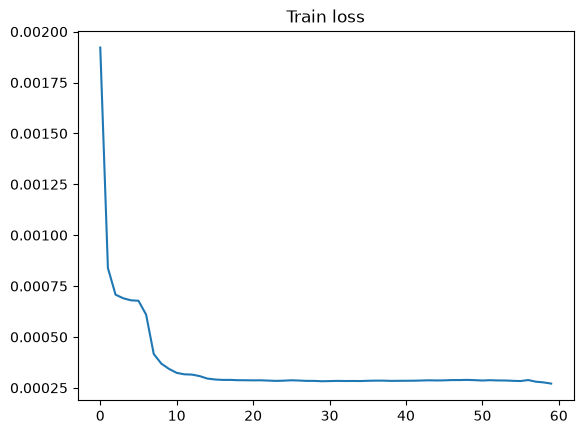

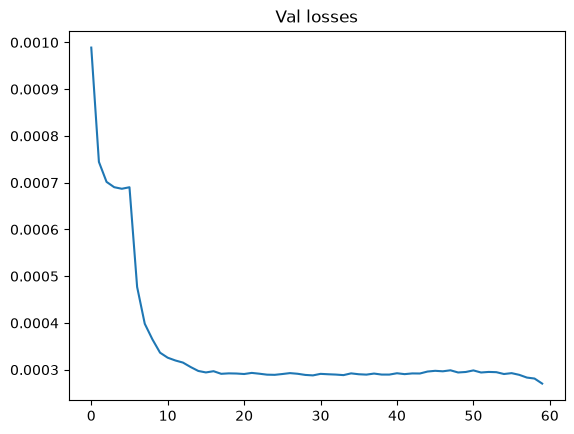

In [11]:
plt.plot(train_losses)
plt.title("Train loss")
plt.show()

plt.plot(val_losses)
plt.title("Val losses")
plt.show()

### Compare classification model performance with and without SAE reconstruction

In [12]:
trimmed_model = TrimmedClsModel(model, sae_model, neurons_to_kill=[], sae_features_layer=SAE_FEATURES_LAYER)

cls_criterion = nn.CrossEntropyLoss()
metrics_calculator = metrics.MetricsCalculator(num_classes=10, average='macro')
print("=========== BASELINE ===========")
# Evaluate the model on clean validation dataset
clean_val_loss = train_utils.cls_evaluate(model, clean_val_dataloader, cls_criterion, metrics_calculator, device)
clean_val_accuracy, clean_val_precision, clean_val_recall, clean_val_f1_score, clean_val_auprc, clean_val_auroc = metrics_calculator.compute_all()

# Evaluate the model on fully colored validation dataset
fully_colored_val_loss = train_utils.cls_evaluate(model, fully_colored_val_dataloader, cls_criterion, metrics_calculator, device)
fully_colored_val_accuracy, fully_colored_val_precision, fully_colored_val_recall, fully_colored_val_f1_score, fully_colored_val_auprc, fully_colored_val_auroc = metrics_calculator.compute_all()

colors_flipped_val_loss = train_utils.cls_evaluate(model, colors_flipped_val_dataloader, cls_criterion, metrics_calculator, device)
colors_flipped_val_accuracy, colors_flipped_val_precision, colors_flipped_val_recall, colors_flipped_val_f1_score, colors_flipped_val_auprc, colors_flipped_val_auroc = metrics_calculator.compute_all()

print("Performance on clean validation set:")
print(f"Clean Val Loss: {clean_val_loss}, Accuracy: {clean_val_accuracy}, Precision: {clean_val_precision}, Recall: {clean_val_recall}, F1 Score: {clean_val_f1_score}, AUPRC: {clean_val_auprc}, AUROC: {clean_val_auroc}")
print("Performance on fully colored validation set:")
print(f"Fully Colored Val Loss: {fully_colored_val_loss}, Accuracy: {fully_colored_val_accuracy}, Precision: {fully_colored_val_precision}, Recall: {fully_colored_val_recall}, F1 Score: {fully_colored_val_f1_score}, AUPRC: {fully_colored_val_auprc}, AUROC: {fully_colored_val_auroc}")
print("Performance on validation set with colors flipped:")
print(f"Colors flipped Val Loss: {colors_flipped_val_loss}, Accuracy: {colors_flipped_val_accuracy}, Precision: {colors_flipped_val_precision}, Recall: {colors_flipped_val_recall}, F1 Score: {colors_flipped_val_f1_score}, AUPRC: {colors_flipped_val_auprc}, AUROC: {colors_flipped_val_auroc}")

print("=========== TRIMMED ===========")
# Evaluate the model on clean validation dataset
clean_val_loss = train_utils.cls_evaluate(trimmed_model, clean_val_dataloader, cls_criterion, metrics_calculator, device)
clean_val_accuracy, clean_val_precision, clean_val_recall, clean_val_f1_score, clean_val_auprc, clean_val_auroc = metrics_calculator.compute_all()

# Evaluate the model on fully colored validation dataset
fully_colored_val_loss = train_utils.cls_evaluate(trimmed_model, fully_colored_val_dataloader, cls_criterion, metrics_calculator, device)
fully_colored_val_accuracy, fully_colored_val_precision, fully_colored_val_recall, fully_colored_val_f1_score, fully_colored_val_auprc, fully_colored_val_auroc = metrics_calculator.compute_all()

colors_flipped_val_loss = train_utils.cls_evaluate(trimmed_model, colors_flipped_val_dataloader, cls_criterion, metrics_calculator, device)
colors_flipped_val_accuracy, colors_flipped_val_precision, colors_flipped_val_recall, colors_flipped_val_f1_score, colors_flipped_val_auprc, colors_flipped_val_auroc = metrics_calculator.compute_all()

print("Performance on clean validation set:")
print(f"Clean Val Loss: {clean_val_loss}, Accuracy: {clean_val_accuracy}, Precision: {clean_val_precision}, Recall: {clean_val_recall}, F1 Score: {clean_val_f1_score}, AUPRC: {clean_val_auprc}, AUROC: {clean_val_auroc}")
print("Performance on fully colored validation set:")
print(f"Fully Colored Val Loss: {fully_colored_val_loss}, Accuracy: {fully_colored_val_accuracy}, Precision: {fully_colored_val_precision}, Recall: {fully_colored_val_recall}, F1 Score: {fully_colored_val_f1_score}, AUPRC: {fully_colored_val_auprc}, AUROC: {fully_colored_val_auroc}")
print("Performance on validation set with colors flipped:")
print(f"Colors flipped Val Loss: {colors_flipped_val_loss}, Accuracy: {colors_flipped_val_accuracy}, Precision: {colors_flipped_val_precision}, Recall: {colors_flipped_val_recall}, F1 Score: {colors_flipped_val_f1_score}, AUPRC: {colors_flipped_val_auprc}, AUROC: {colors_flipped_val_auroc}")


=========== BASELINE ===========


Evaluating:   0%|          | 0/375 [00:00<?, ?it/s]/Users/jakub/ml/sae/Sparse-Autoencoders-for-Vision-in-Pytorch/.venv/lib/python3.12/site-packages/torcheval/metrics/functional/classification/accuracy.py:275: UserWarning: The reduce argument of torch.scatter with Tensor src is deprecated and will be removed in a future PyTorch release. Use torch.scatter_reduce instead for more reduction options. (Triggered internally at /Users/runner/work/pytorch/pytorch/aten/src/ATen/native/TensorAdvancedIndexing.cpp:228.)
  num_correct = mask.new_zeros(num_classes).scatter_(0, target, mask, reduce="add")
Evaluating: 100%|██████████| 375/375 [00:01<00:00, 323.13it/s]


Performance on clean validation set:
Clean Val Loss: 0.014600206649318959, Accuracy: 0.8697797060012817, Precision: 0.8697797060012817, Recall: 0.8697797060012817, F1 Score: 0.8695934414863586, AUPRC: 0.916117787361145, AUROC: 0.9793814420700073
Performance on fully colored validation set:
Fully Colored Val Loss: 0.00013471145794089048, Accuracy: 0.9987508654594421, Precision: 0.9987508654594421, Recall: 0.9987508654594421, F1 Score: 0.9987426996231079, AUPRC: 0.9998343586921692, AUROC: 0.9999397397041321
Performance on validation set with colors flipped:
Colors flipped Val Loss: 0.15088139323393504, Accuracy: 0.31806516647338867, Precision: 0.31806516647338867, Recall: 0.31806516647338867, F1 Score: 0.2966172397136688, AUPRC: 0.3592463433742523, AUROC: 0.7136240005493164
=========== TRIMMED ===========


Evaluating: 100%|██████████| 375/375 [00:01<00:00, 292.06it/s]

Performance on clean validation set:
Clean Val Loss: 0.020079452695169798, Accuracy: 0.8606241345405579, Precision: 0.8606241345405579, Recall: 0.8606241345405579, F1 Score: 0.860392689704895, AUPRC: 0.8919548988342285, AUROC: 0.9752320051193237
Performance on fully colored validation set:
Fully Colored Val Loss: 0.00020174574235799506, Accuracy: 0.9981660842895508, Precision: 0.9981660842895508, Recall: 0.9981660842895508, F1 Score: 0.9981525540351868, AUPRC: 0.999444842338562, AUROC: 0.9998415112495422
Performance on validation set with colors flipped:
Colors flipped Val Loss: 0.24322141001621883, Accuracy: 0.32833442091941833, Precision: 0.32833442091941833, Recall: 0.32833442091941833, F1 Score: 0.283444881439209, AUPRC: 0.33644771575927734, AUROC: 0.7071932554244995


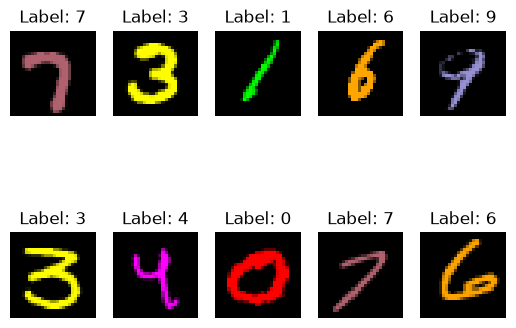

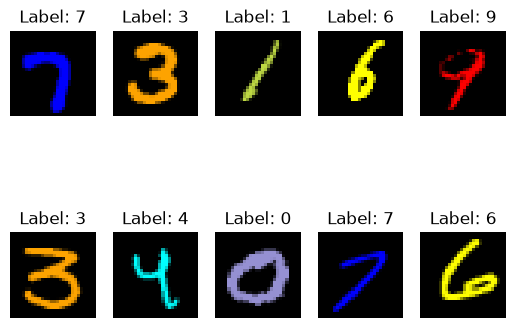

In [13]:
plot_utils.show_from_dataset(val_dataset, range(0, 10))
plot_utils.show_from_dataset(colors_flipped_val_dataset, range(0, 10))

In [14]:
for i in range(10):
	input, target = val_dataset[i]
	input = input.to(device)
	input = input.unsqueeze(0)
	embedding = model.fc[:SAE_FEATURES_LAYER+1](input)

	output, hidden = sae_model(embedding)
	values, indices = torch.topk(hidden, SAE_TOPK)
	print(f"Colors not flipped {i}: {indices}")

	input, target = colors_flipped_val_dataset[i]
	input = input.to(device)
	input = input.unsqueeze(0)
	embedding = model.fc[:SAE_FEATURES_LAYER+1](input)

	output, hidden = sae_model(embedding)
	values, indices = torch.topk(hidden, SAE_TOPK)
	print(f"Colors flipped {i}: {indices}")

Colors not flipped 0: tensor([[10, 59]], device='mps:0')
Colors flipped 0: tensor([[62, 60]], device='mps:0')
Colors not flipped 1: tensor([[59, 34]], device='mps:0')
Colors flipped 1: tensor([[34, 59]], device='mps:0')
Colors not flipped 2: tensor([[16,  2]], device='mps:0')
Colors flipped 2: tensor([[ 2, 16]], device='mps:0')
Colors not flipped 3: tensor([[23, 19]], device='mps:0')
Colors flipped 3: tensor([[23,  2]], device='mps:0')
Colors not flipped 4: tensor([[60,  7]], device='mps:0')
Colors flipped 4: tensor([[23, 37]], device='mps:0')
Colors not flipped 5: tensor([[59, 34]], device='mps:0')
Colors flipped 5: tensor([[59, 34]], device='mps:0')
Colors not flipped 6: tensor([[37, 17]], device='mps:0')
Colors flipped 6: tensor([[32, 16]], device='mps:0')
Colors not flipped 7: tensor([[54, 38]], device='mps:0')
Colors flipped 7: tensor([[38, 61]], device='mps:0')
Colors not flipped 8: tensor([[10,  9]], device='mps:0')
Colors flipped 8: tensor([[62, 60]], device='mps:0')
Colors not

In [15]:
from torch.return_types import topk


@torch.no_grad()
def get_representatives(cls_model, sae_model, dataloader, n_representatives=10, topk_value=0):
	"""
	Given classification model and sae model returns n_representatives examples from dataset which activate each SAE hidden layer neurons the most
	"""
	sae_hidden_dim = sae_model.hidden_dim

	top_values = torch.full((sae_hidden_dim, n_representatives), -float('inf'), device=device)

	representatives = torch.full((sae_hidden_dim, n_representatives), -1, dtype=torch.long, device=device)

	current_img_offset = 0

	for inputs, targets in tqdm.tqdm(dataloader):
		inputs = inputs.to(device)
		bs = inputs.size(0)
		
		embeddings = cls_model.fc[:SAE_FEATURES_LAYER+1](inputs)

		if hasattr(sae_model, "topk"):
			output, hidden = sae_model(embeddings, apply_topk=False)
		else:
			output, hidden = sae_model(embeddings)

		if topk_value:
			values, indices = torch.topk(hidden, topk_value, dim=1)
			sparse_hidden = torch.zeros_like(hidden)
			sparse_hidden.scatter_(1, indices, values)
			hidden = sparse_hidden
			
		batch_indices = torch.arange(current_img_offset, current_img_offset + bs, device=device)
		
		batch_hidden = hidden.T 
		
		# Create dataset indices for the current batch
		batch_indices = batch_indices.unsqueeze(0).expand(sae_hidden_dim, bs)
		
		# Concatenate the running top N with the new batch
		combined_values = torch.cat([top_values, batch_hidden], dim=1)
		combined_indices = torch.cat([representatives, batch_indices], dim=1)
		
		# Find the global winners so far
		top_values, topk_args = torch.topk(combined_values, k=n_representatives, dim=1)
		
		# Gather the winning image indices
		representatives = torch.gather(combined_indices, dim=1, index=topk_args)
		
		current_img_offset += bs

	return representatives, top_values

In [16]:
n_representatives = 10

clean_val_representatives, clean_val_top_values = get_representatives(model, sae_model, clean_val_dataloader, n_representatives, topk_value=0)
fully_colored_val_representatives, fully_colored_val_top_values = get_representatives(model, sae_model, fully_colored_val_dataloader, n_representatives, topk_value=0)
colors_flipped_val_representatives, colors_flipped_val_top_values = get_representatives(model, sae_model, colors_flipped_val_dataloader, n_representatives, topk_value=0)

100%|██████████| 375/375 [00:00<00:00, 1565.95it/s]


Showing representative samples for 64 out of 64 sae neurons
Neuron: 0


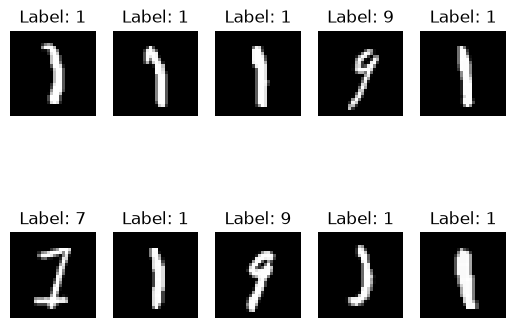

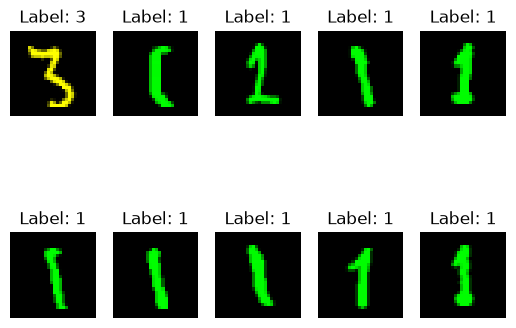

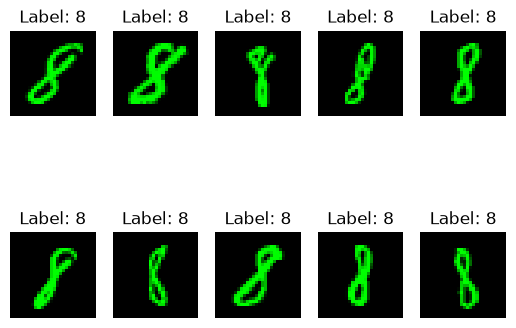

Neuron: 1


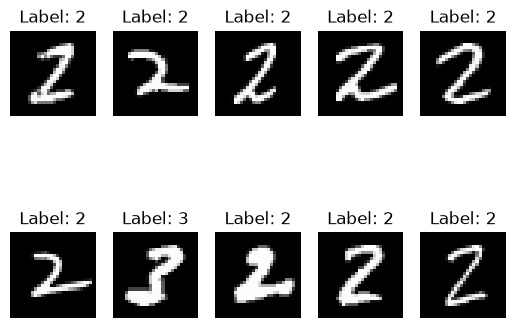

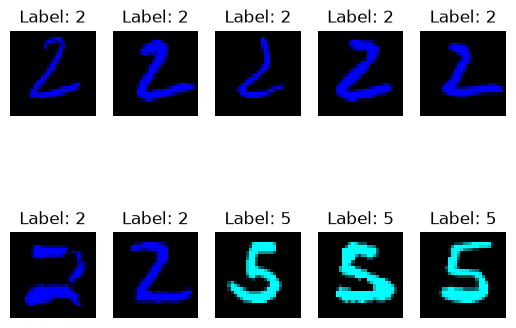

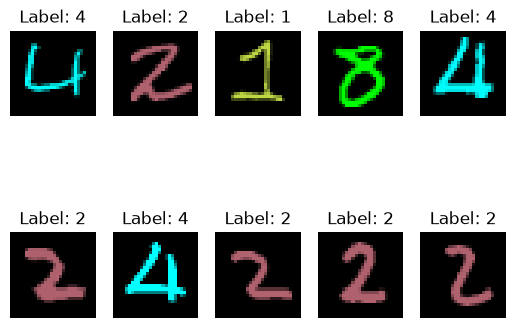

Neuron: 2


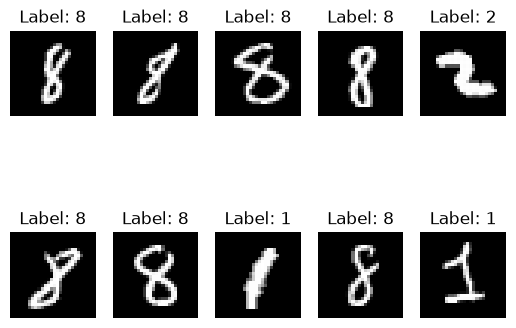

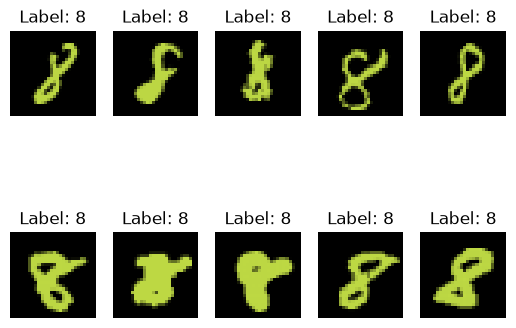

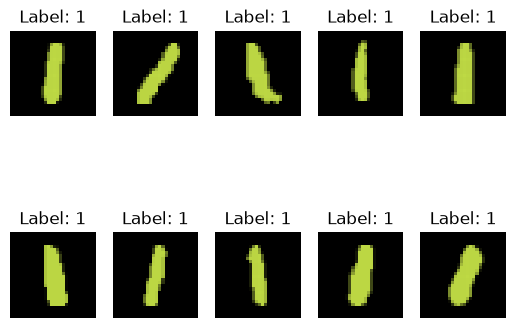

Neuron: 3


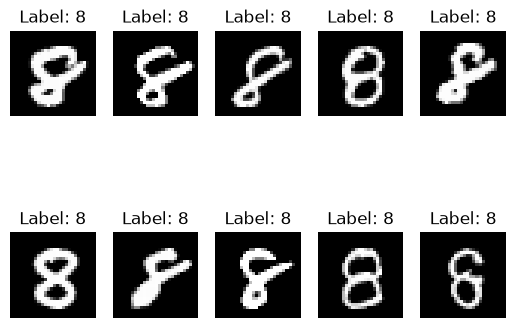

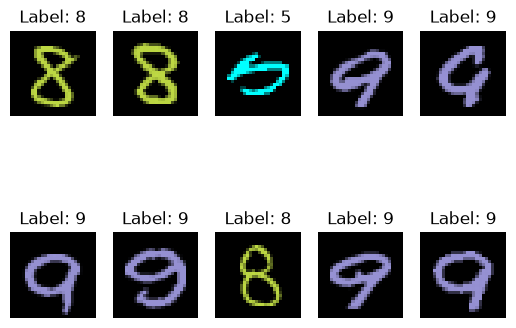

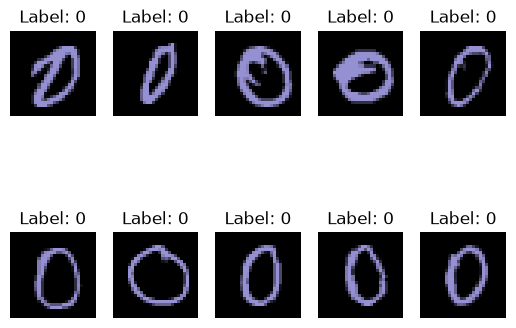

Neuron: 4


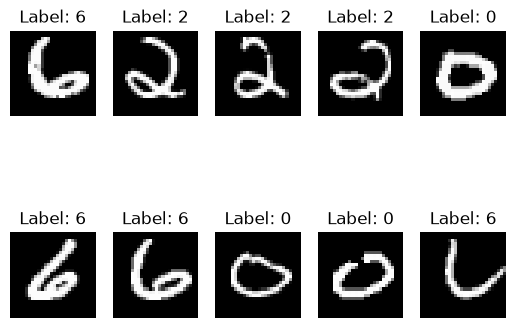

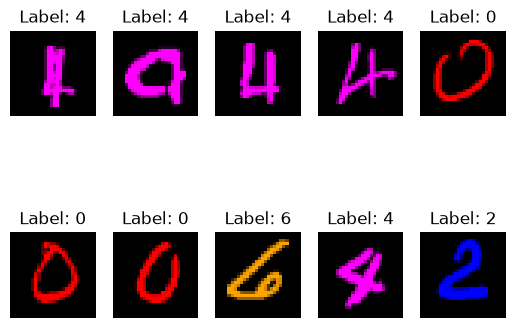

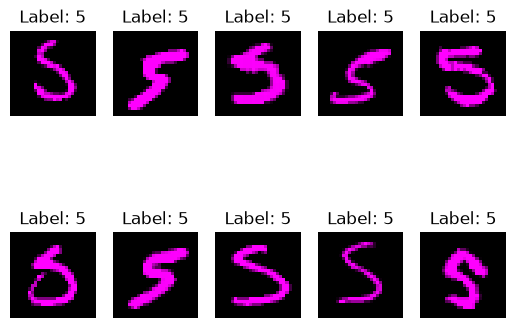

Neuron: 5


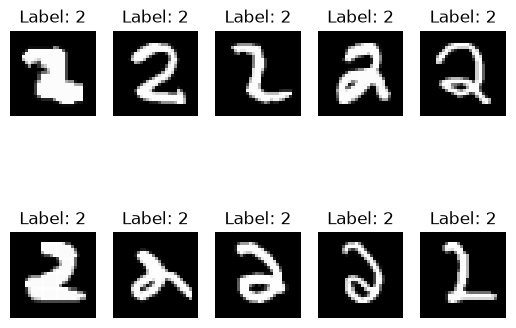

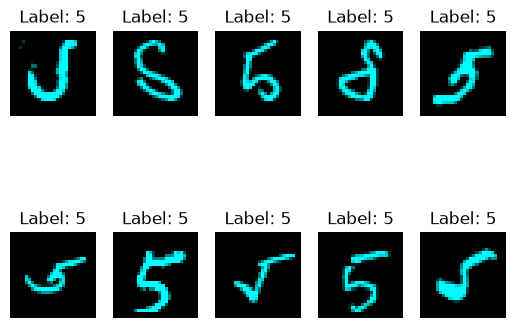

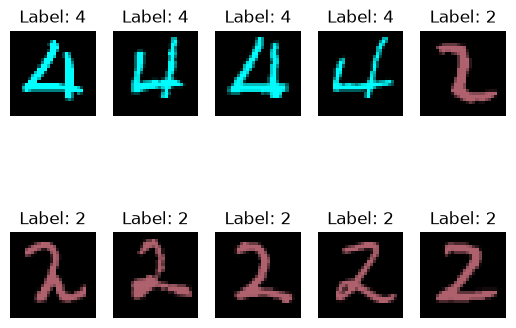

Neuron: 6


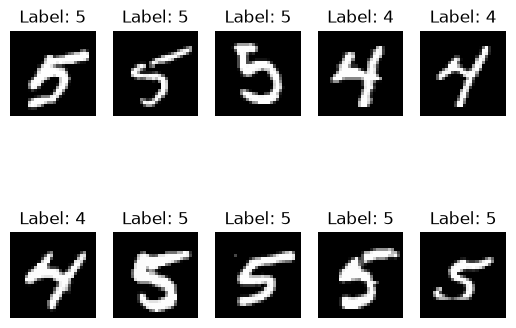

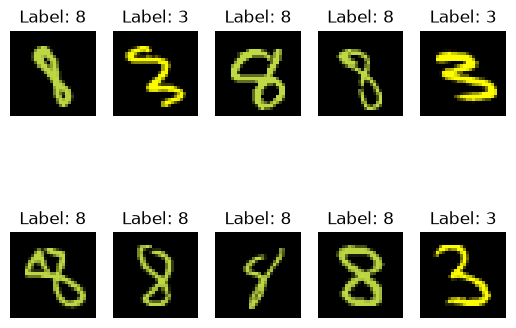

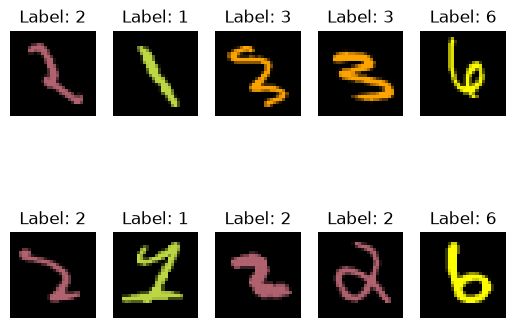

Neuron: 7


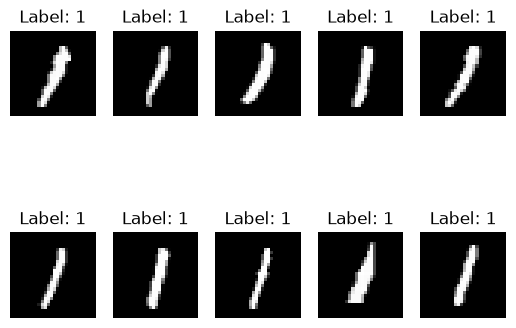

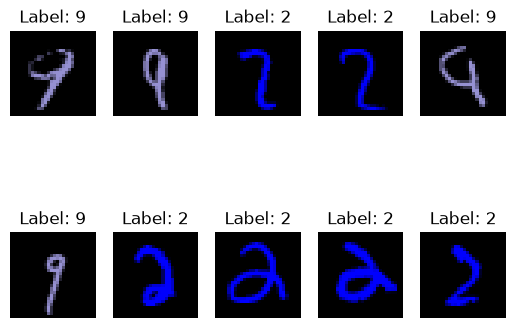

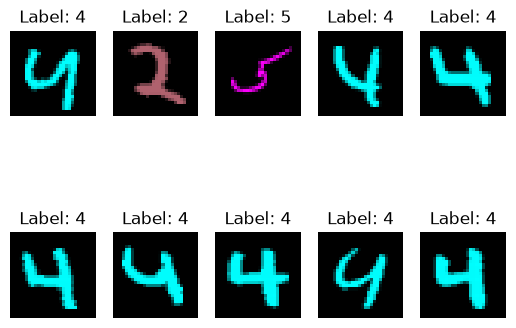

Neuron: 8


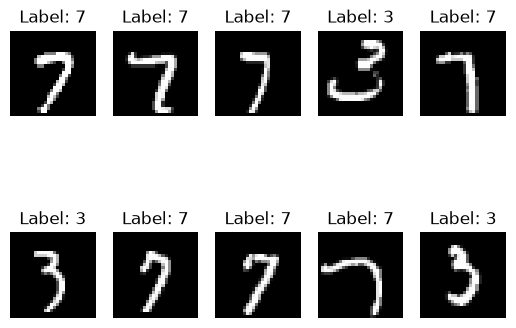

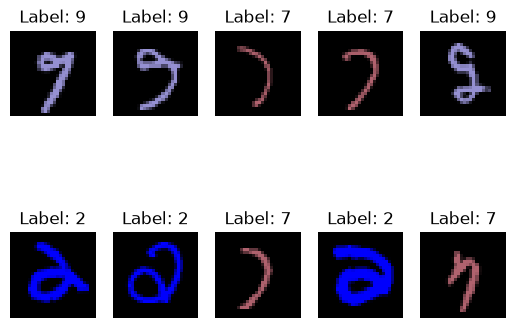

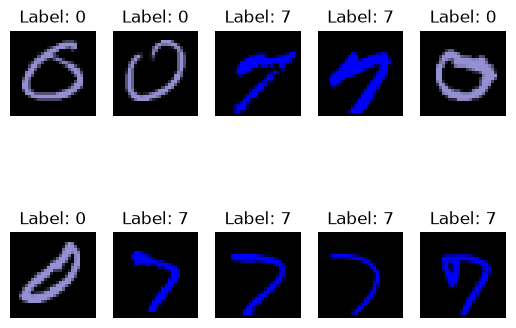

Neuron: 9


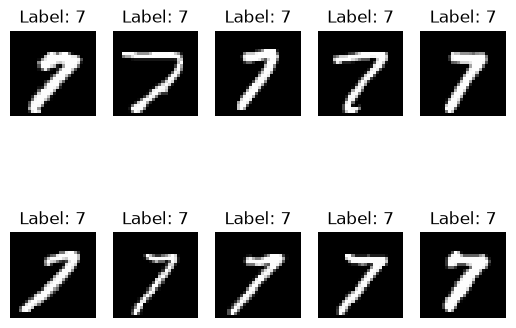

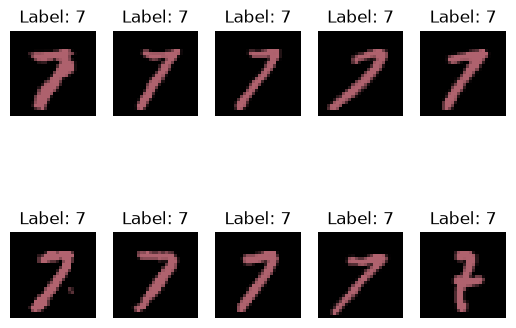

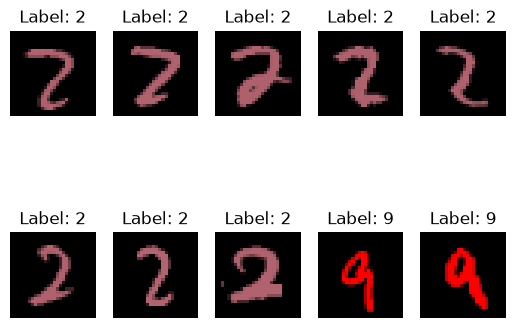

Neuron: 10


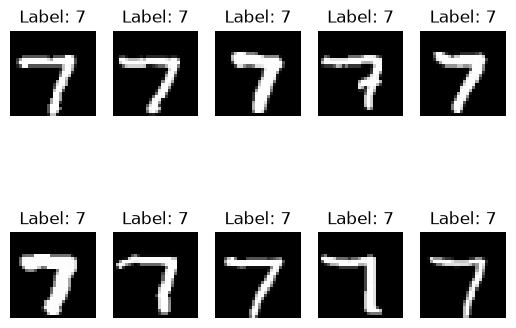

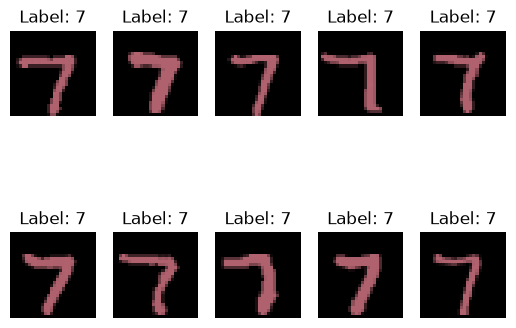

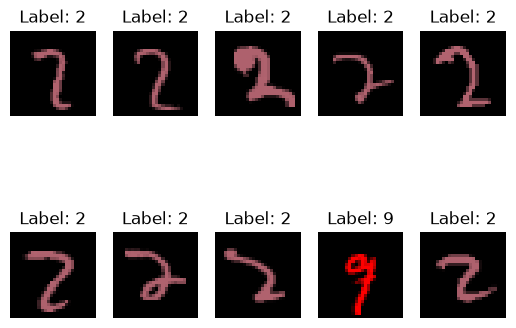

Neuron: 11


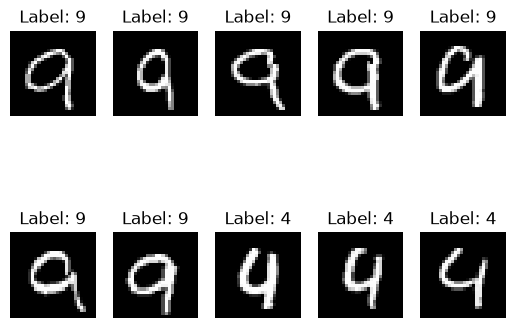

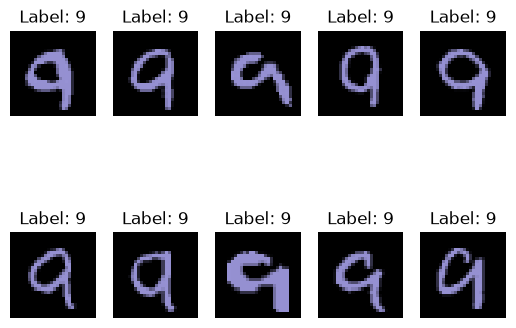

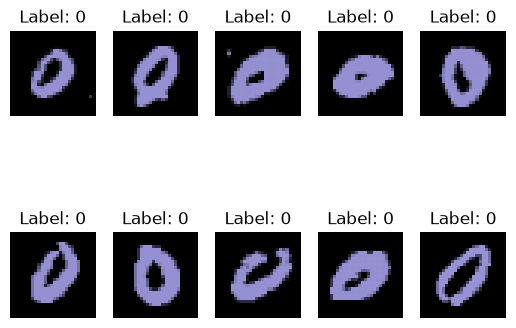

Neuron: 12


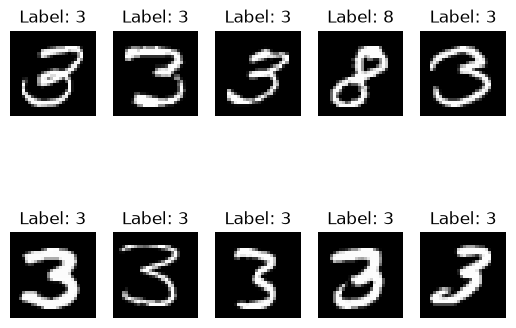

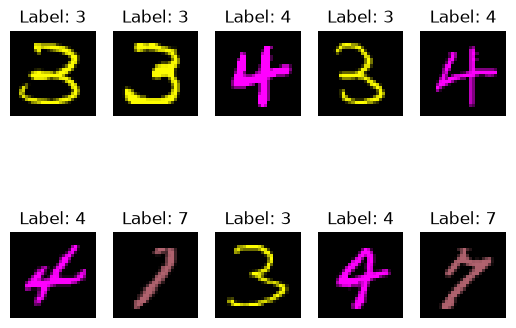

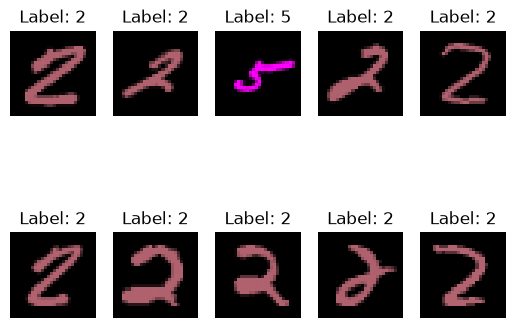

Neuron: 13


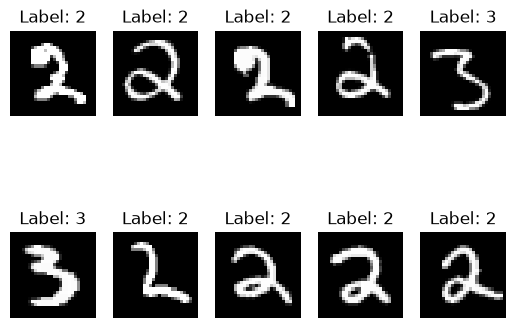

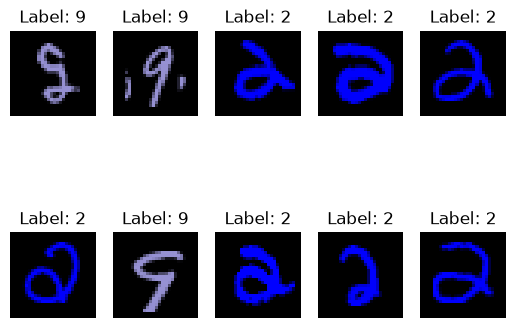

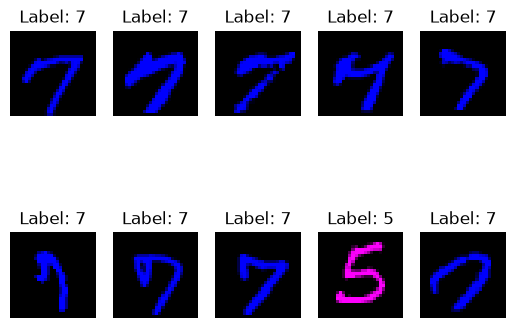

Neuron: 14


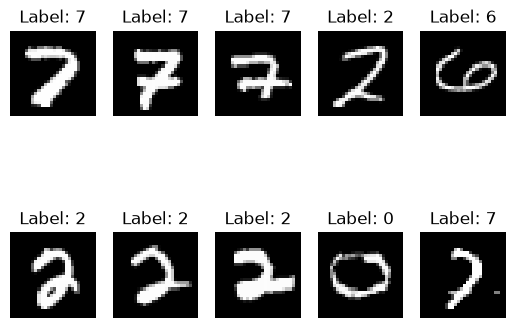

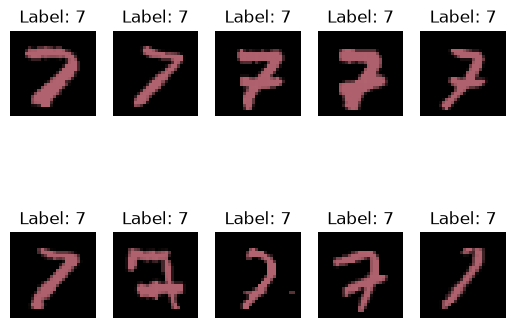

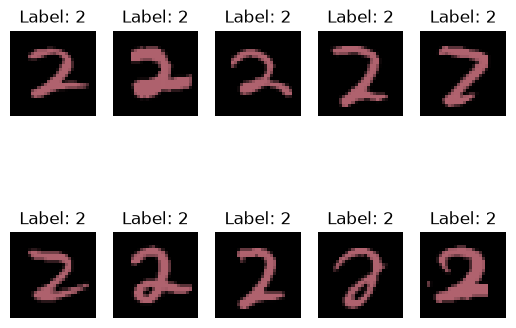

Neuron: 15


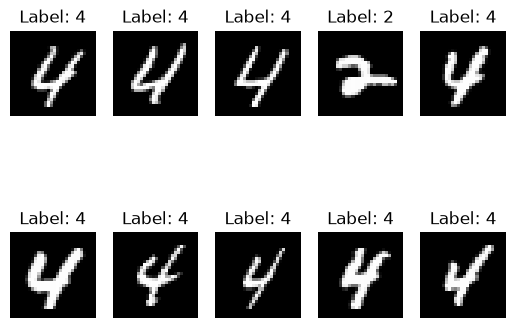

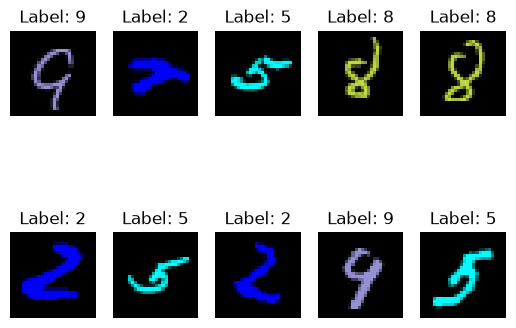

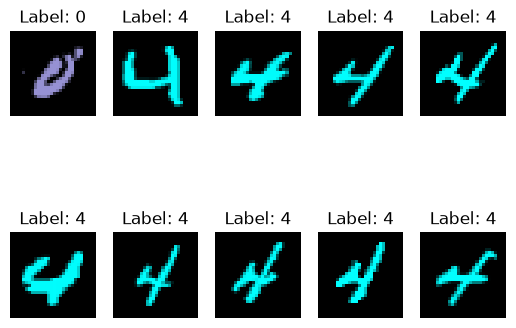

Neuron: 16


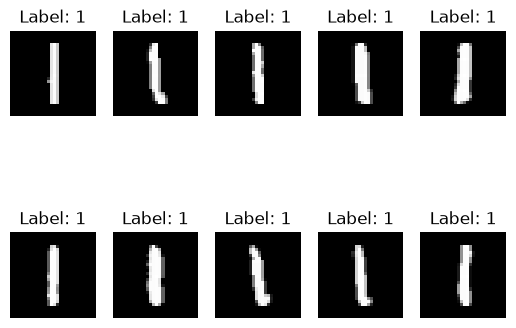

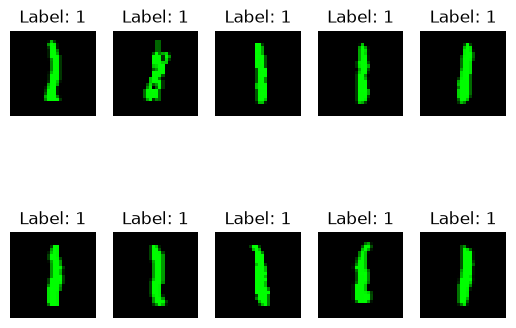

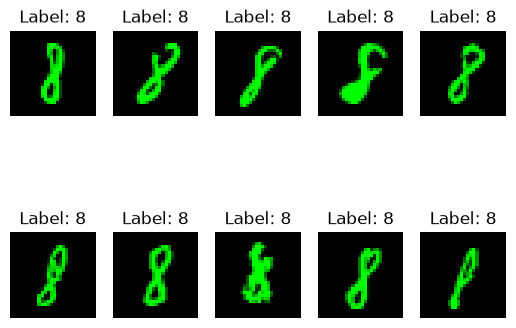

Neuron: 17


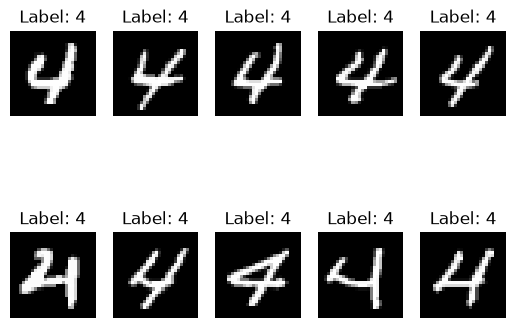

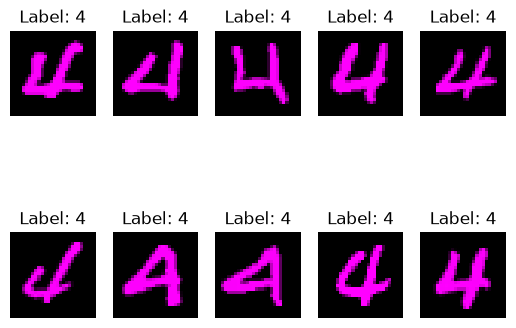

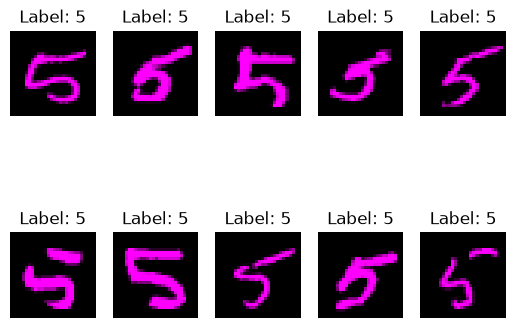

Neuron: 18


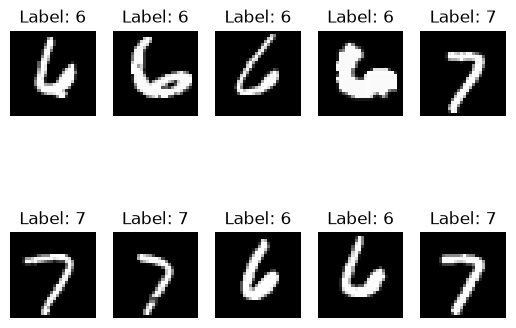

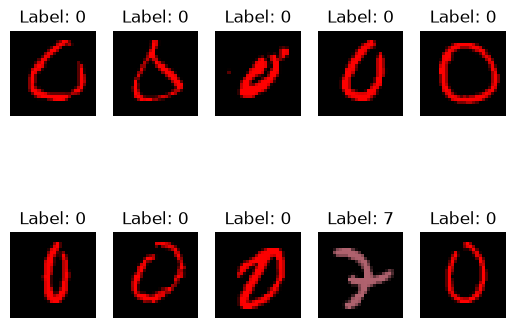

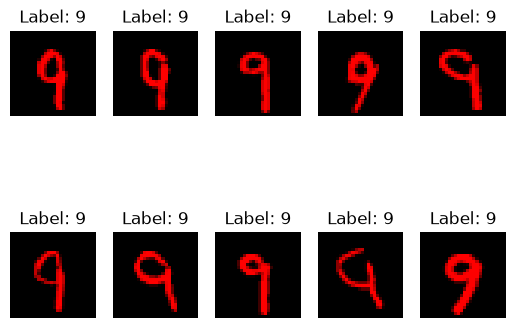

Neuron: 19


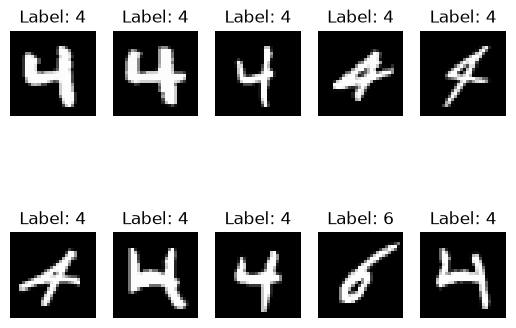

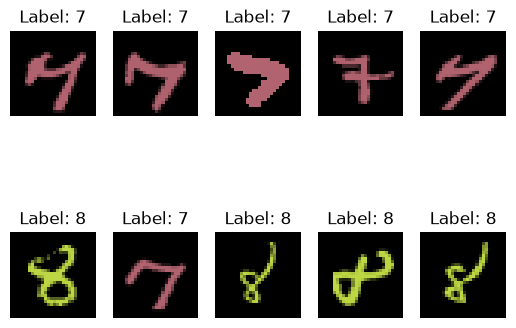

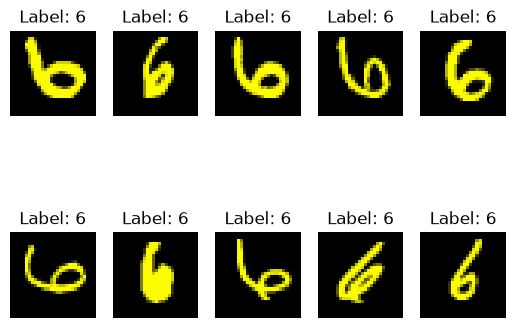

Neuron: 20


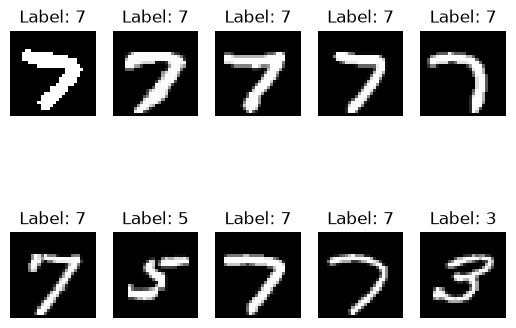

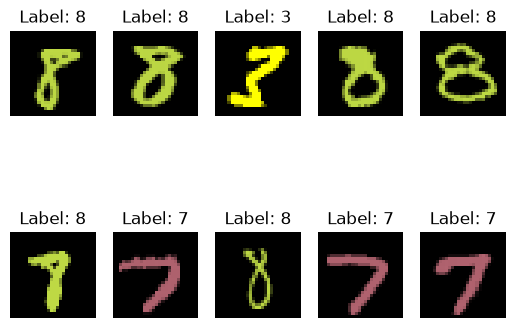

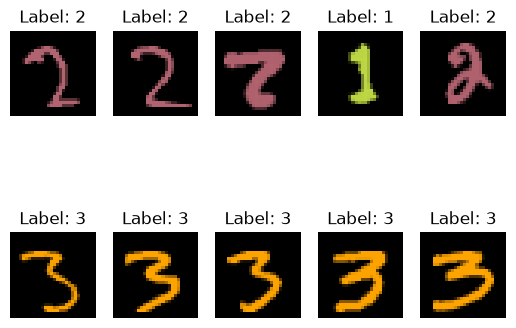

Neuron: 21


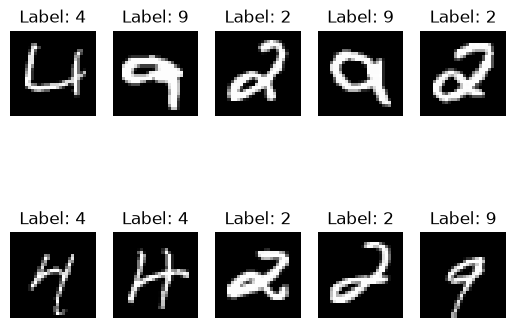

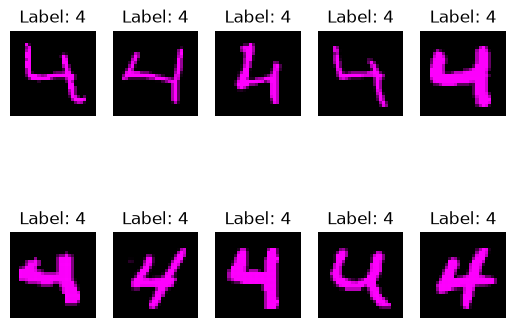

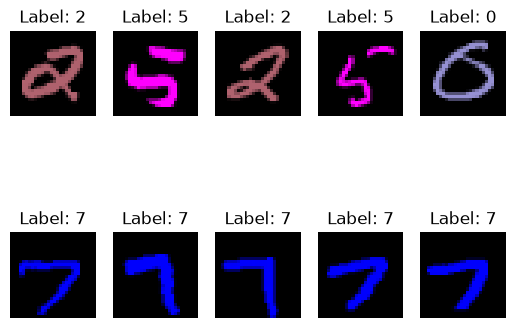

Neuron: 22


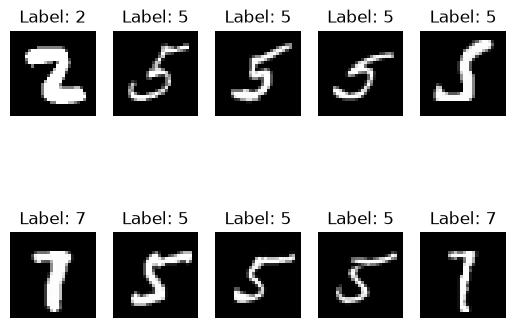

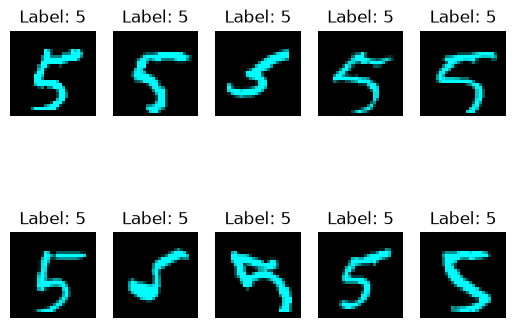

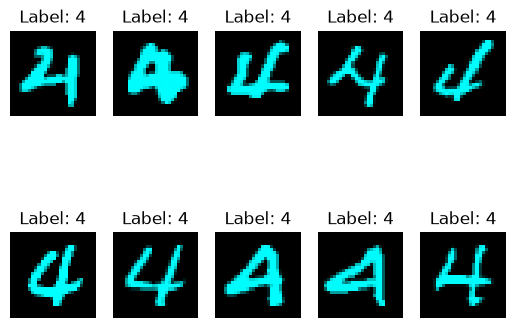

Neuron: 23


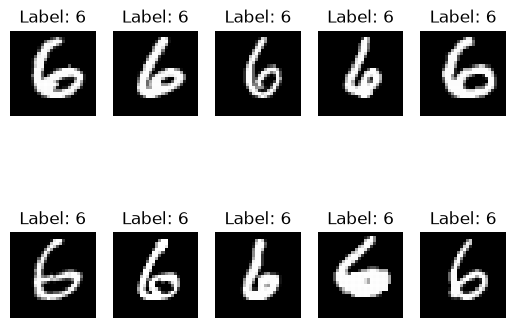

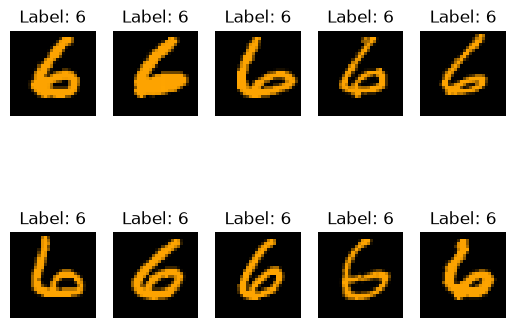

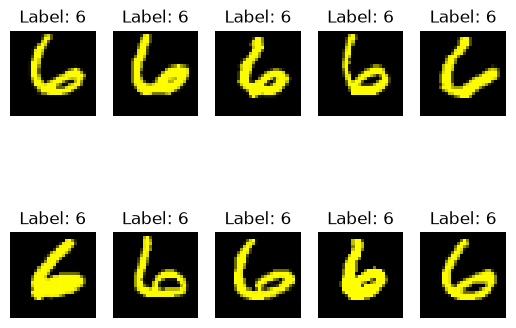

Neuron: 24


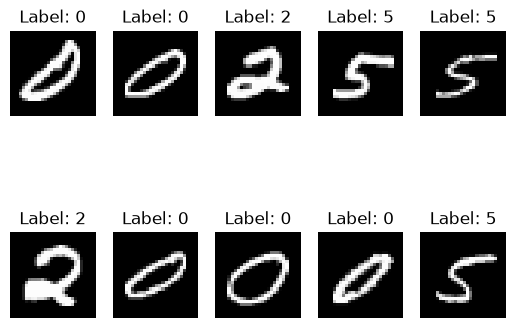

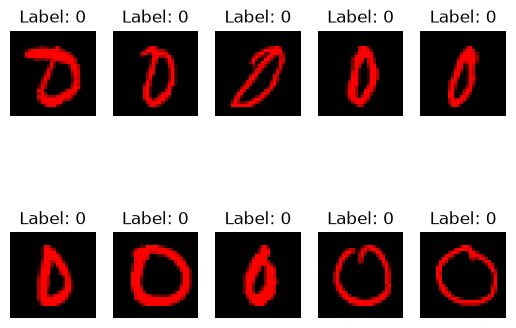

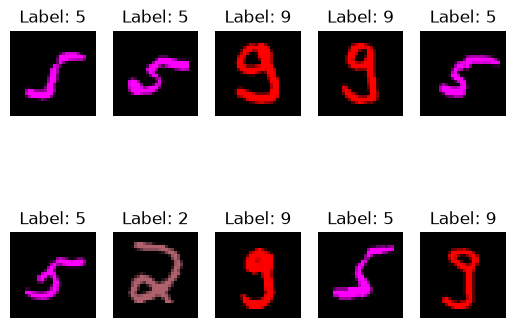

Neuron: 25


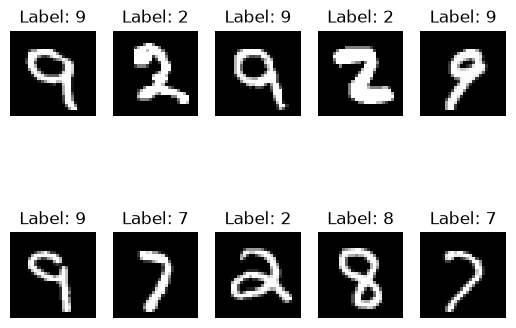

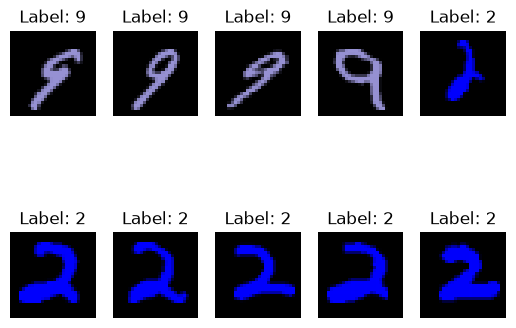

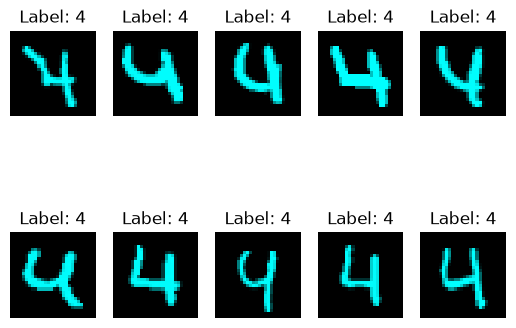

Neuron: 26


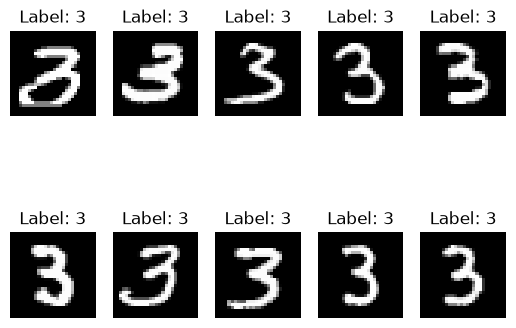

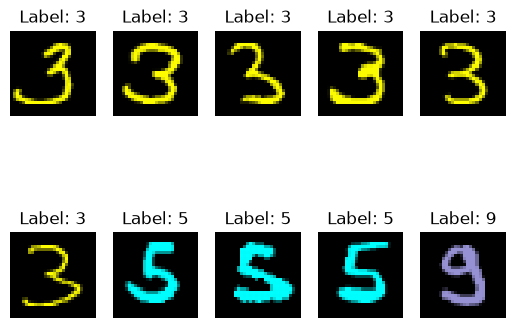

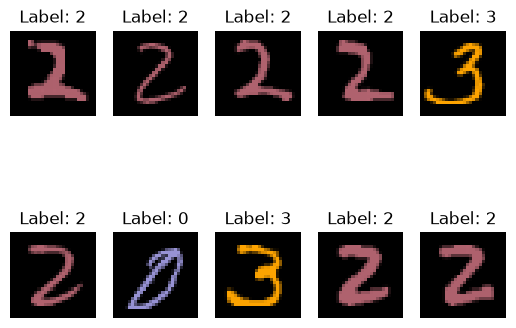

Neuron: 27


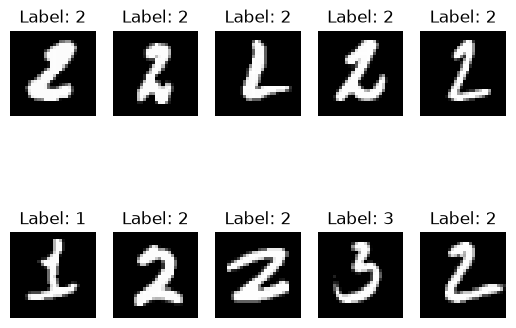

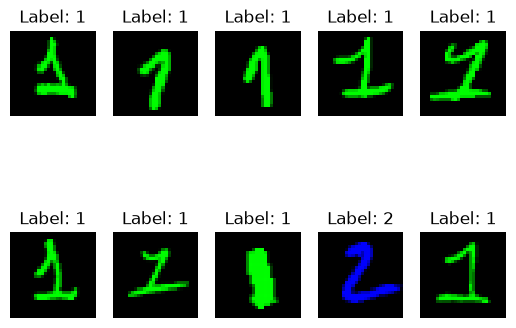

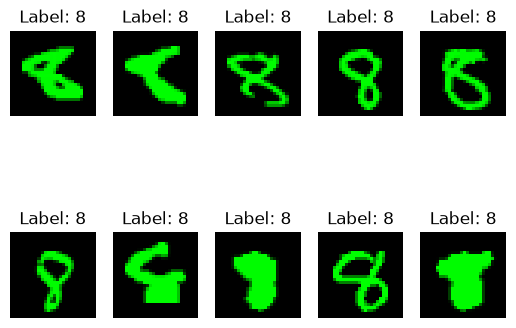

Neuron: 28


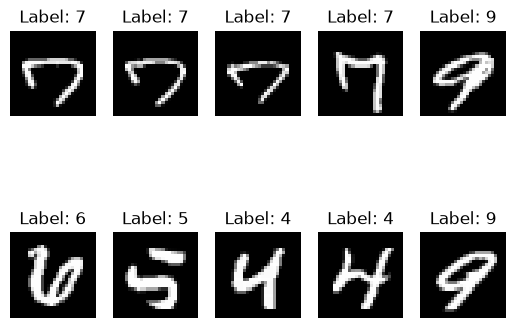

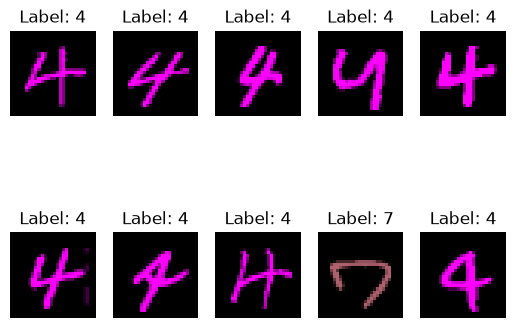

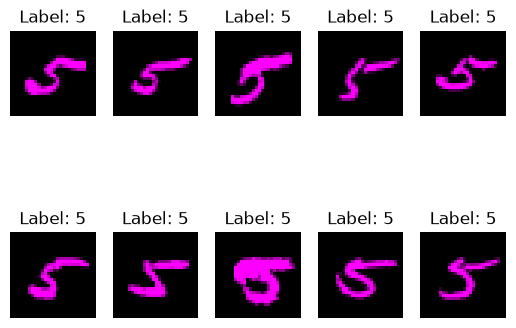

Neuron: 29


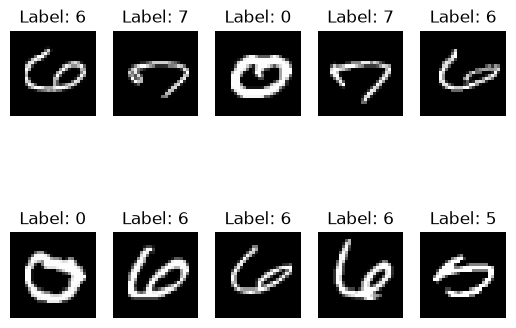

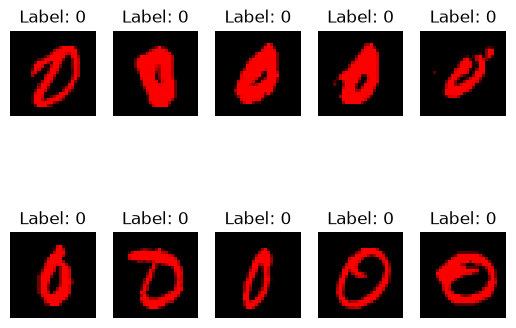

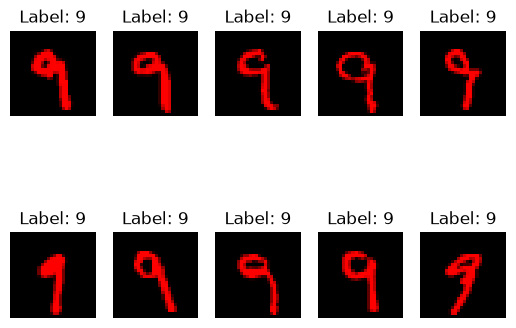

Neuron: 30


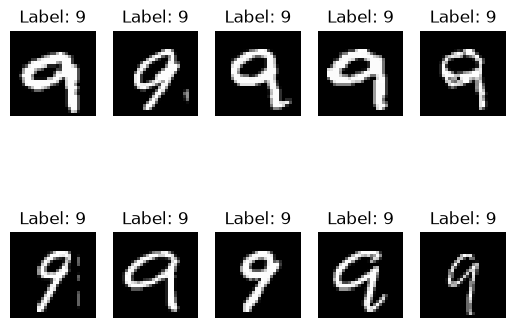

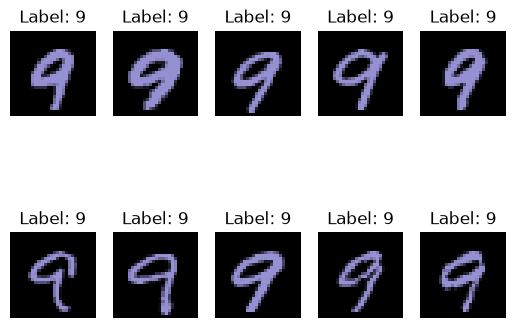

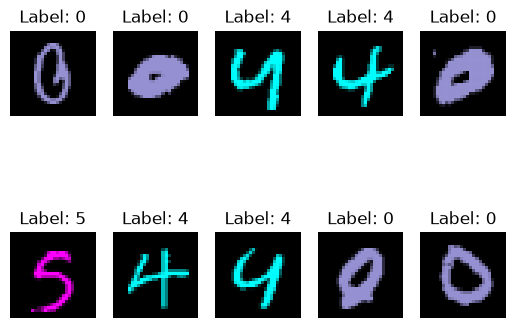

Neuron: 31


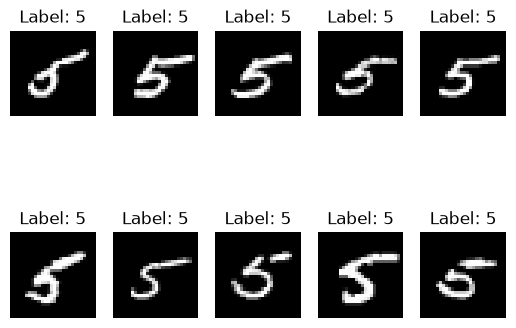

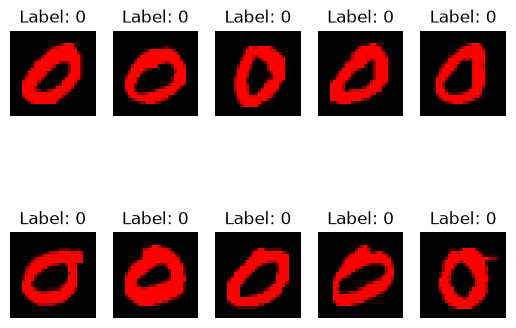

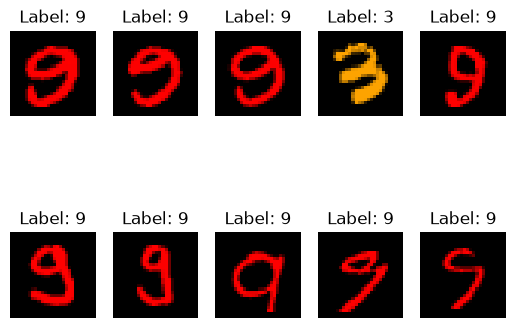

Neuron: 32


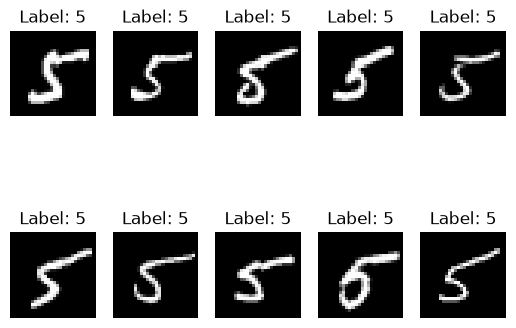

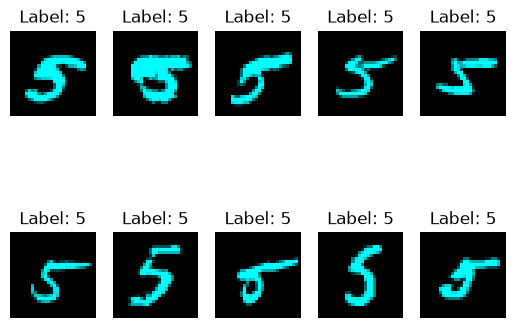

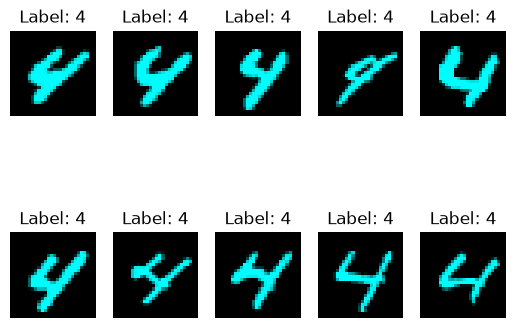

Neuron: 33


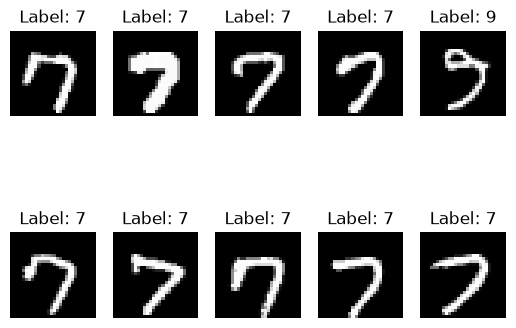

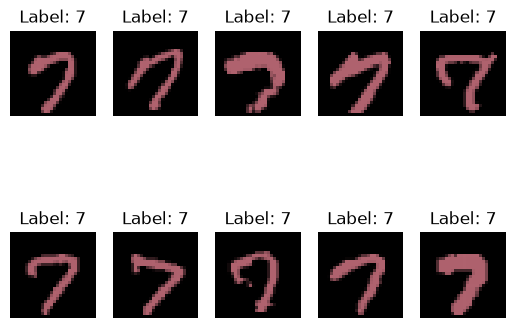

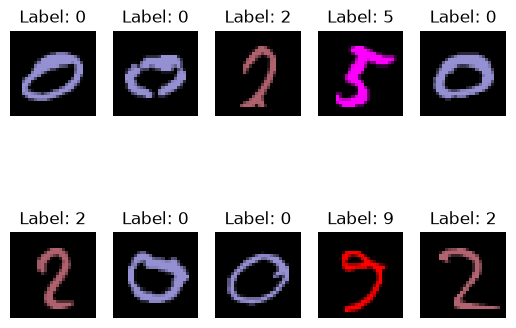

Neuron: 34


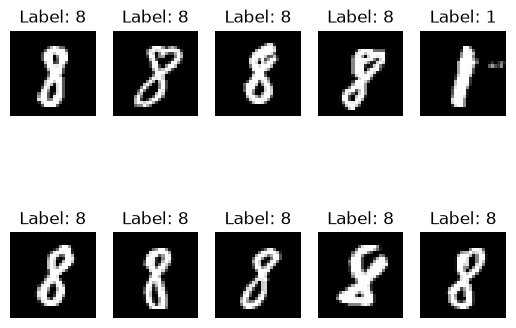

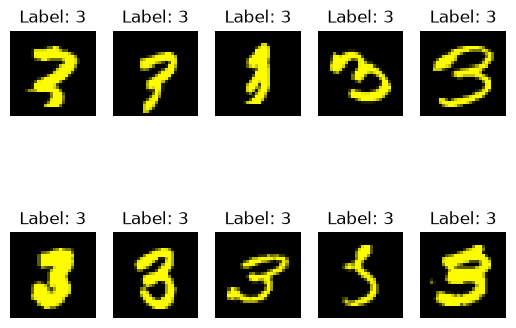

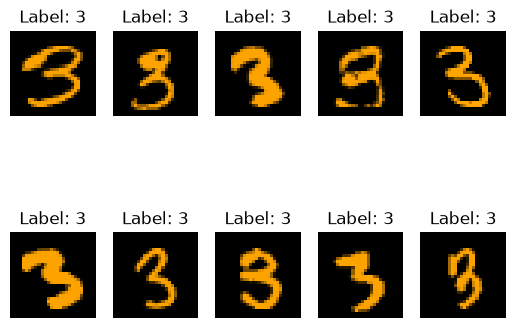

Neuron: 35


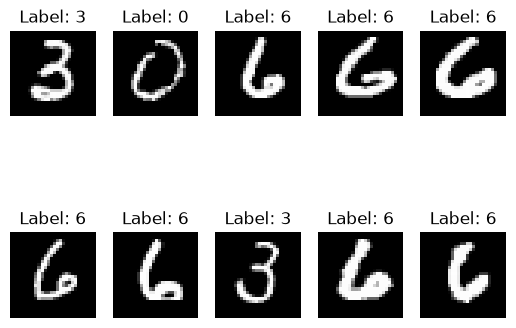

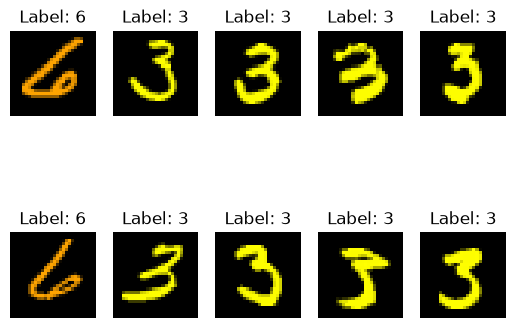

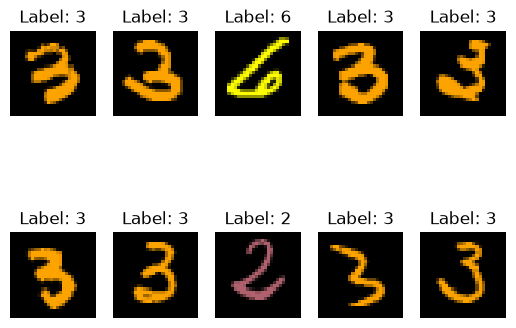

Neuron: 36


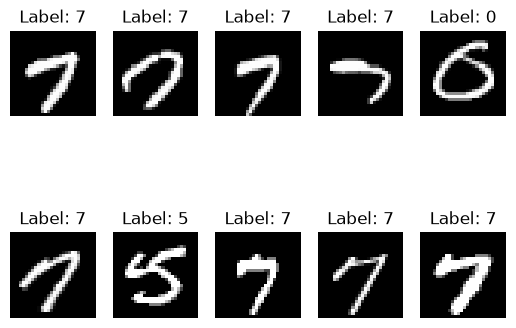

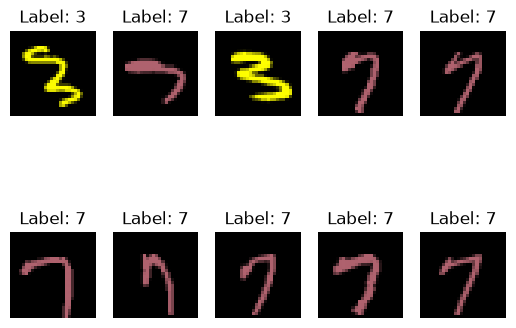

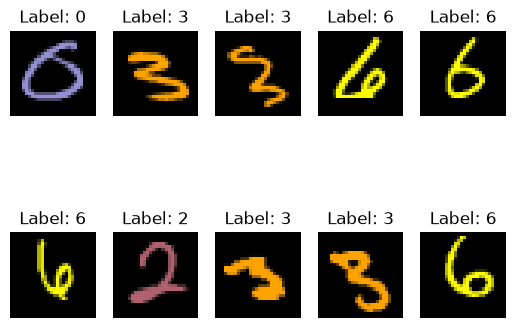

Neuron: 37


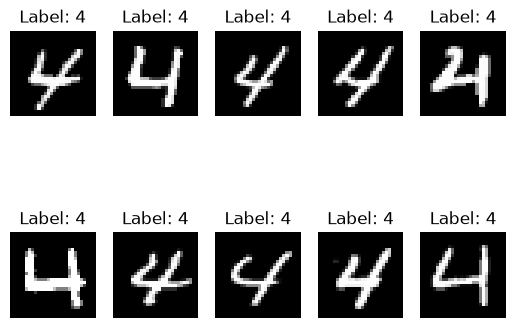

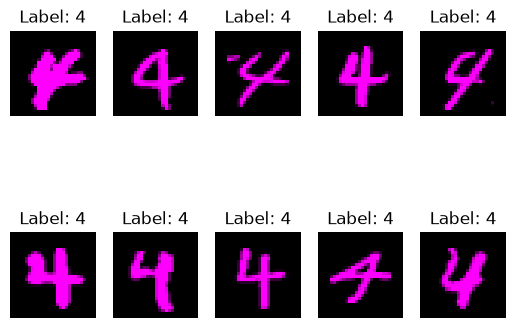

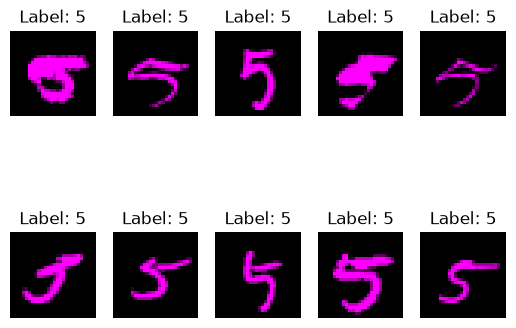

Neuron: 38


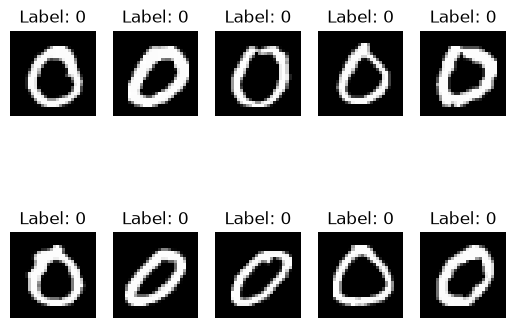

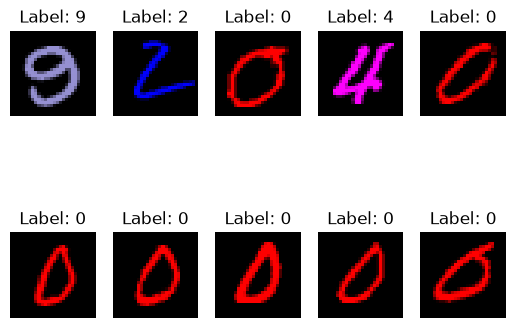

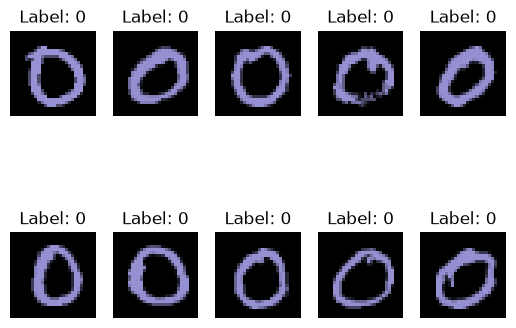

Neuron: 39


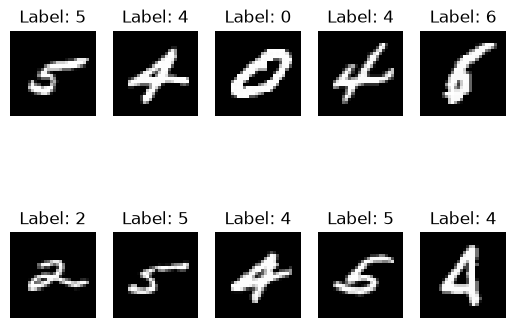

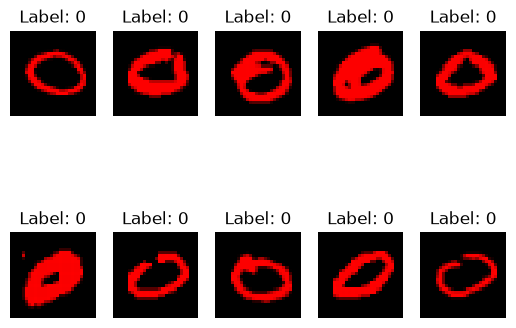

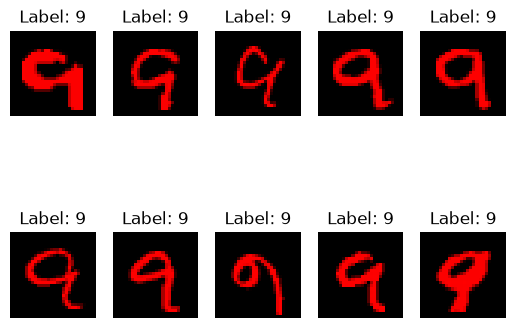

Neuron: 40


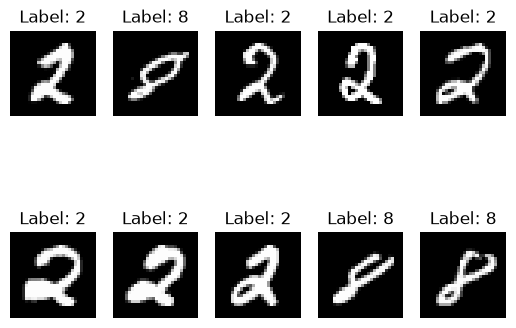

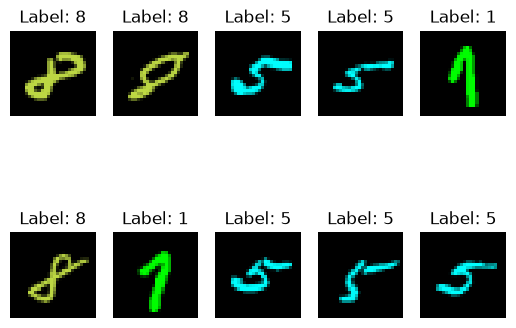

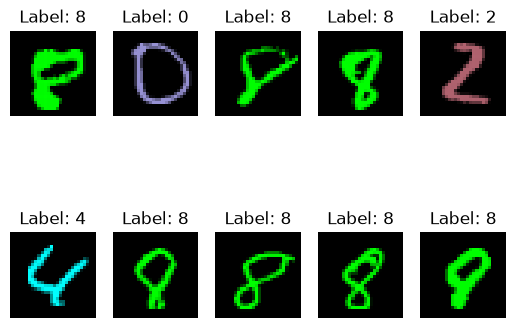

Neuron: 41


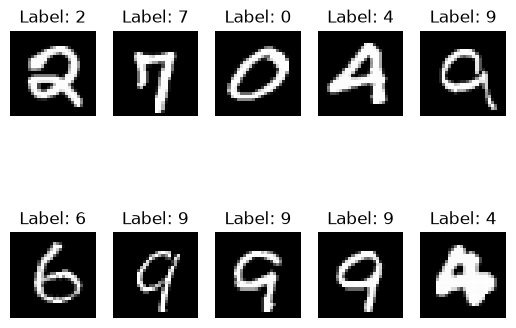

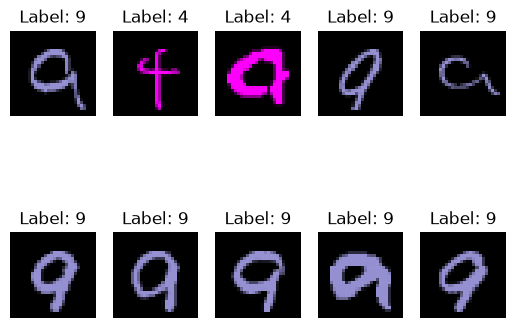

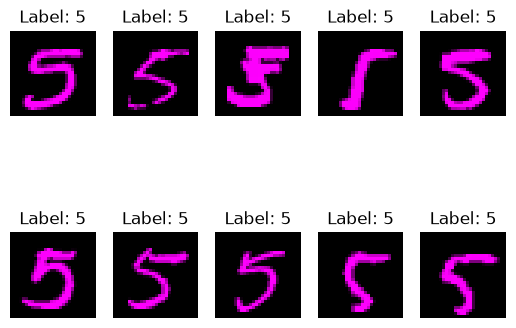

Neuron: 42


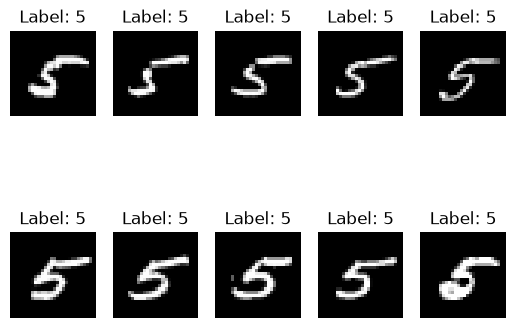

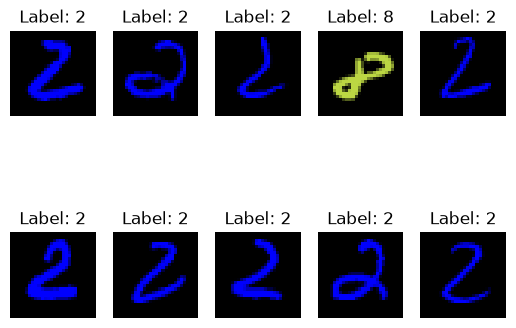

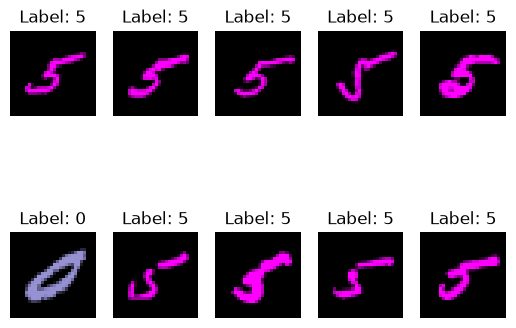

Neuron: 43


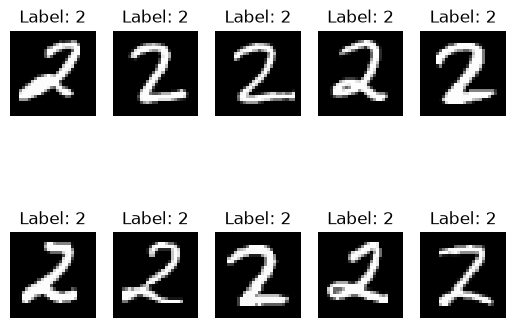

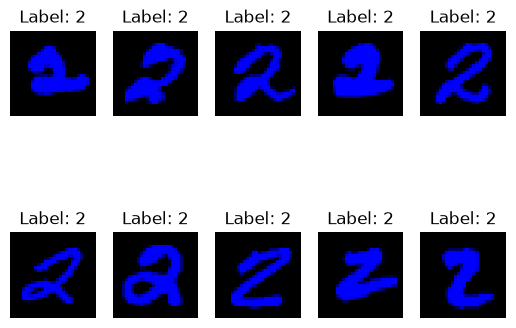

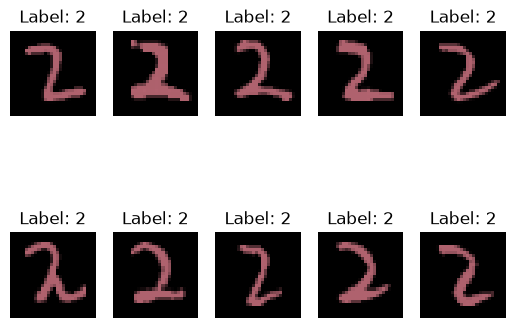

Neuron: 44


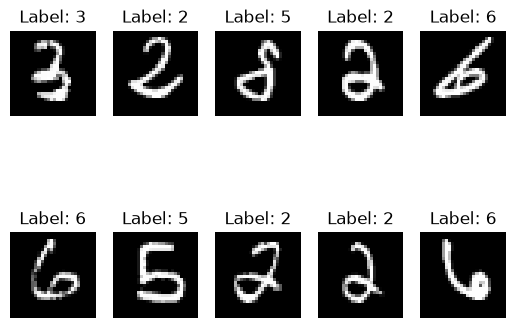

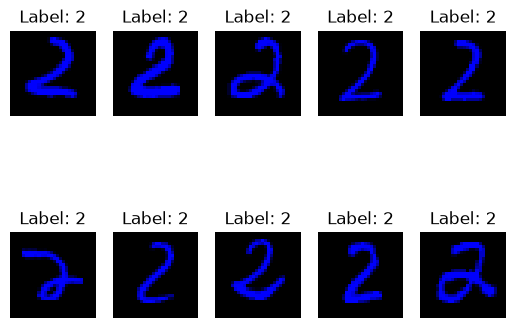

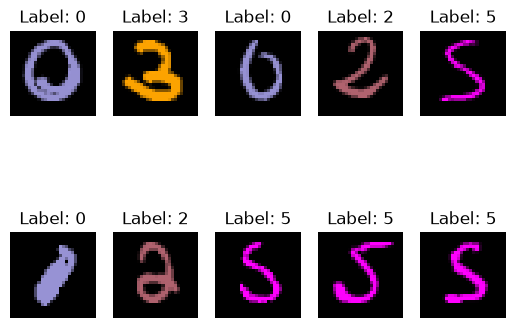

Neuron: 45


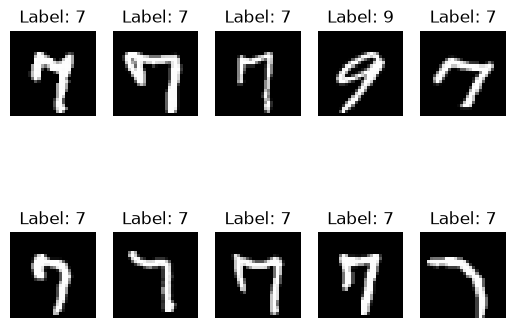

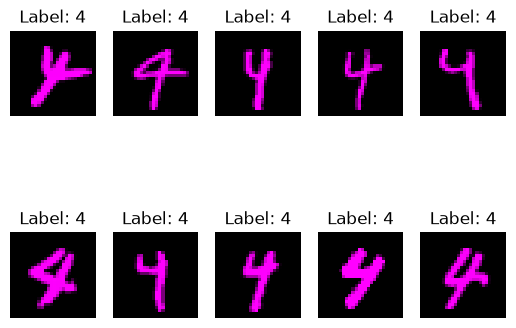

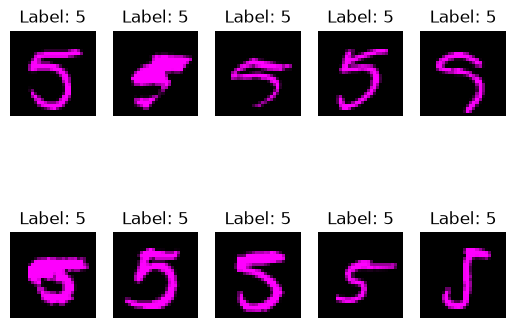

Neuron: 46


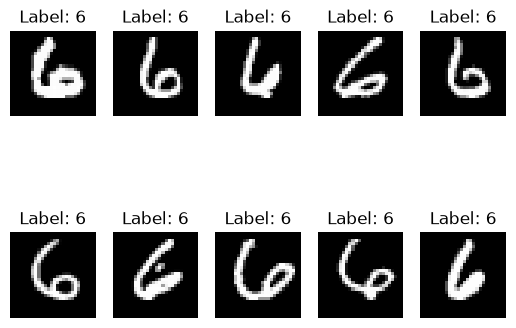

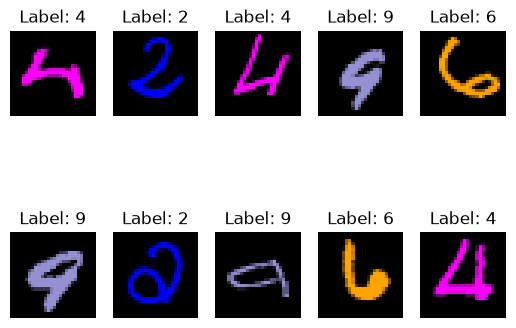

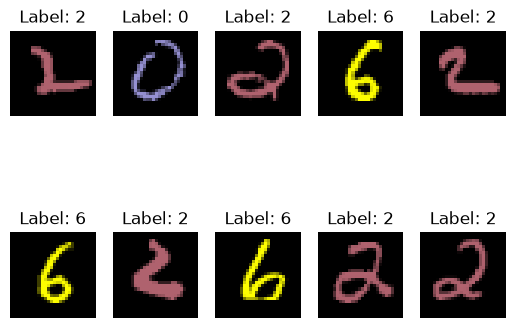

Neuron: 47


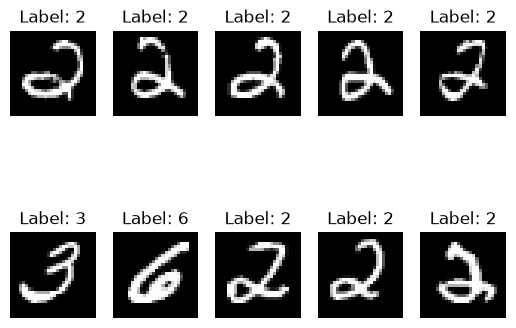

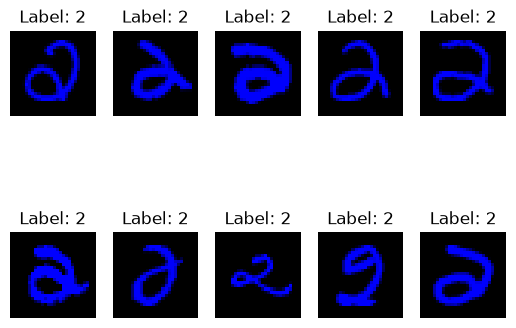

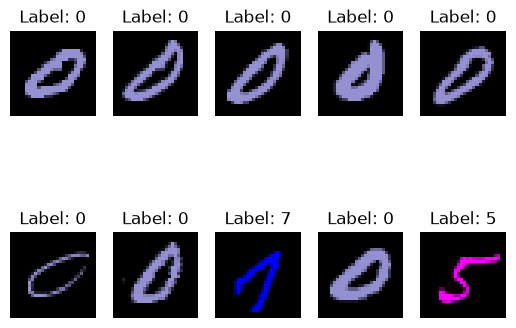

Neuron: 48


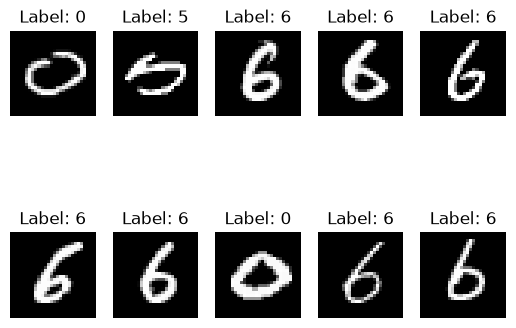

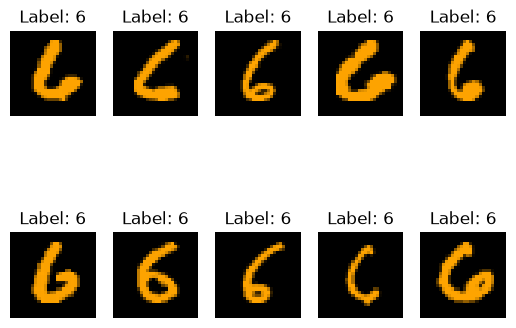

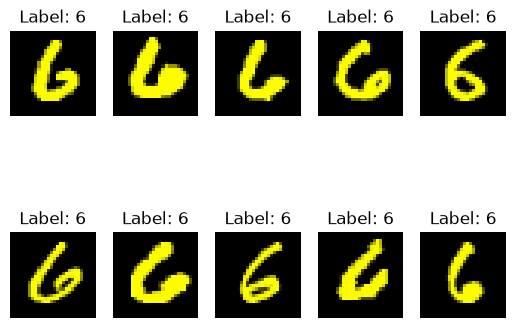

Neuron: 49


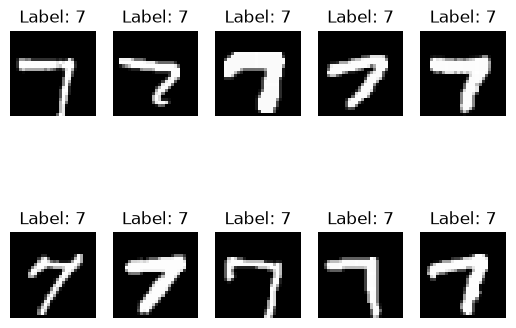

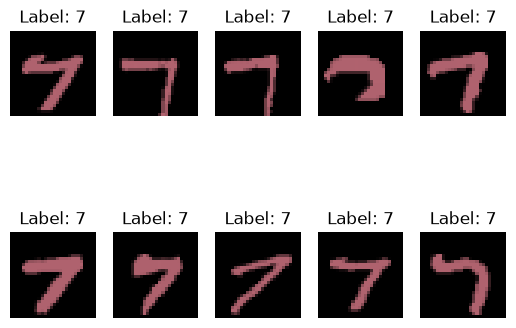

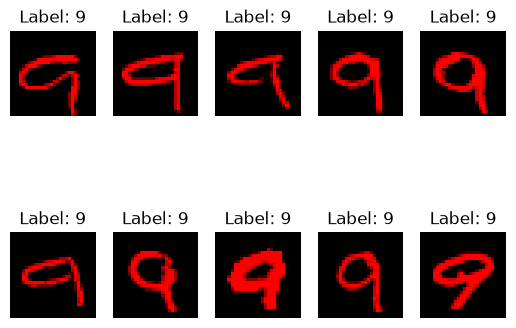

Neuron: 50


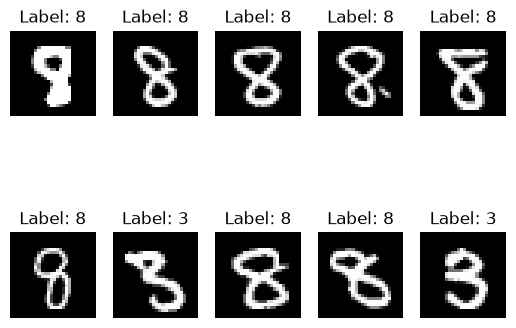

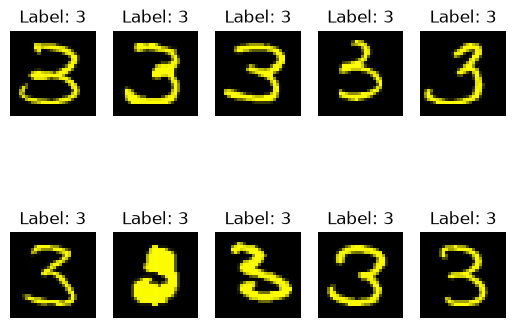

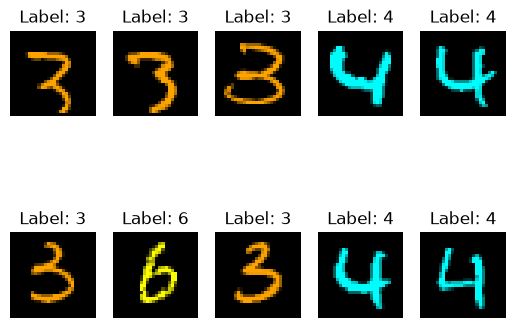

Neuron: 51


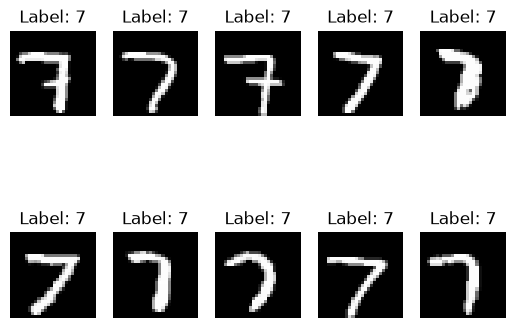

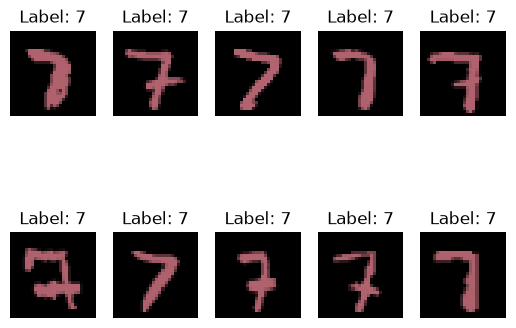

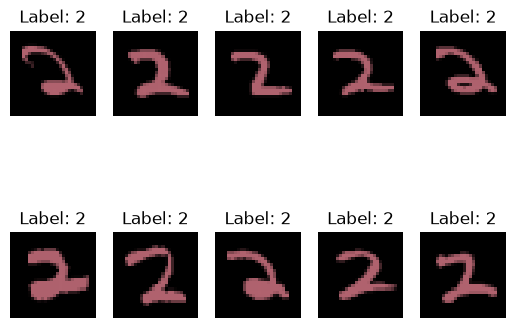

Neuron: 52


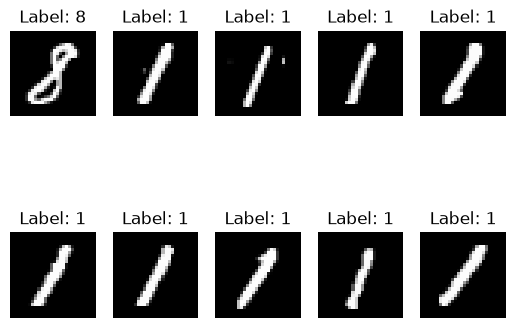

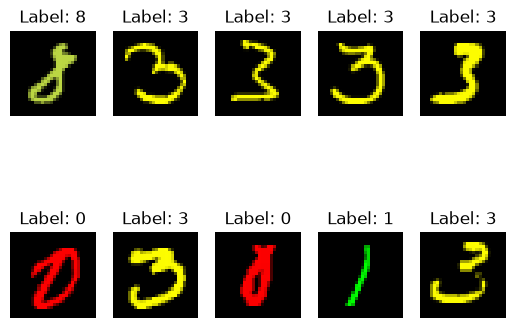

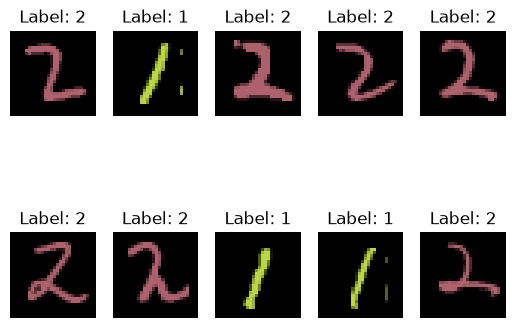

Neuron: 53


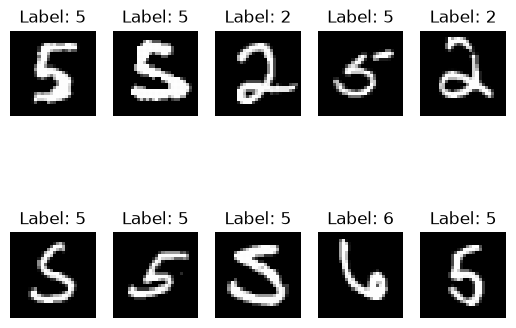

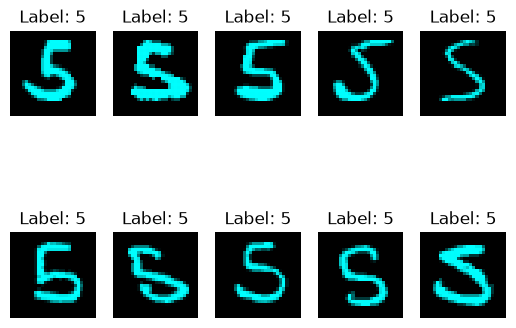

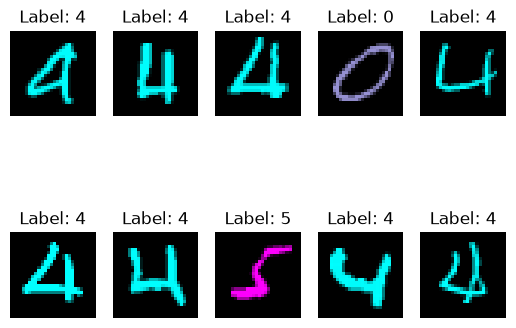

Neuron: 54


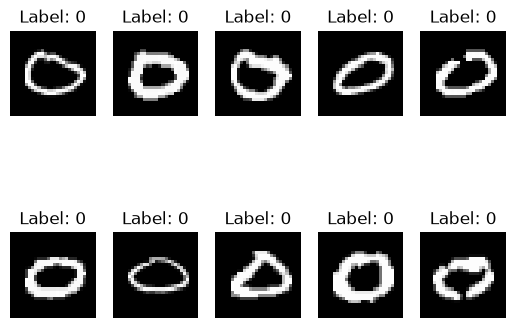

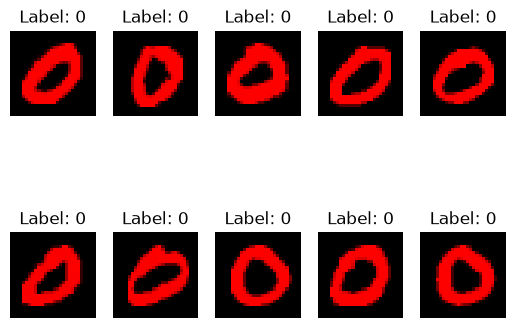

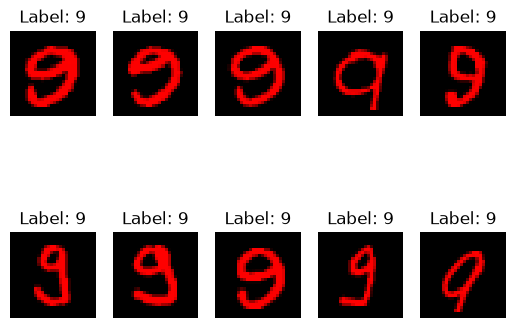

Neuron: 55


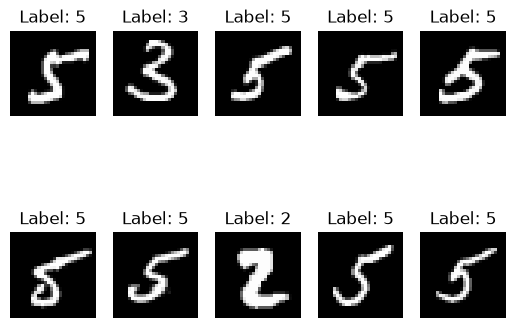

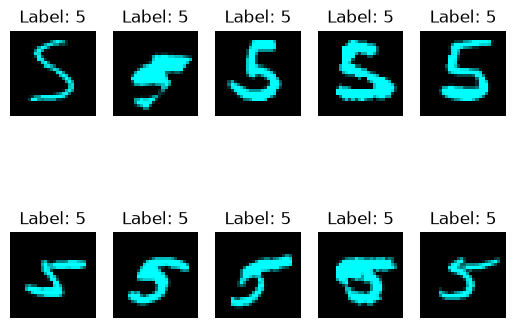

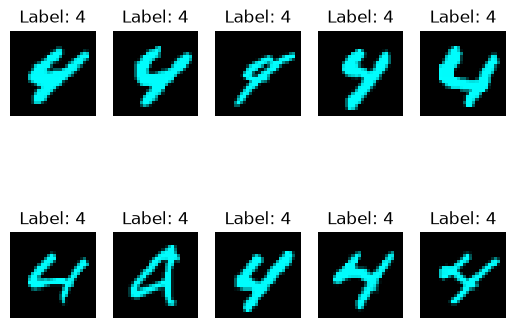

Neuron: 56


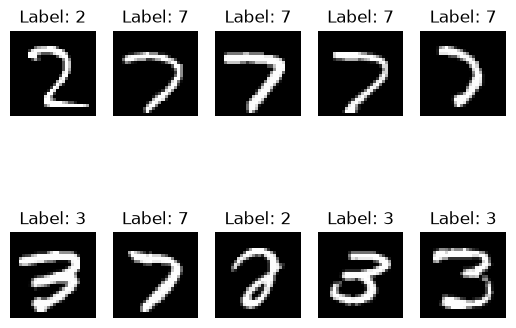

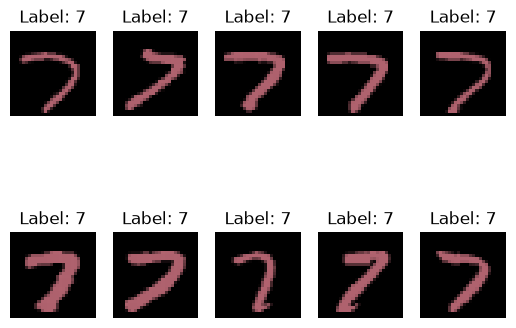

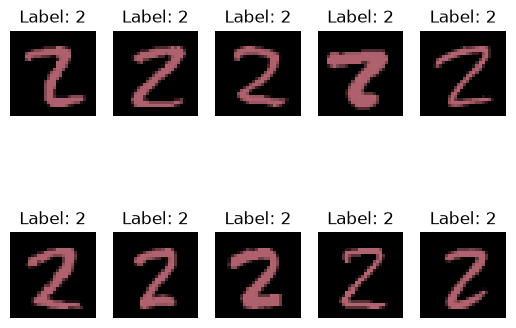

Neuron: 57


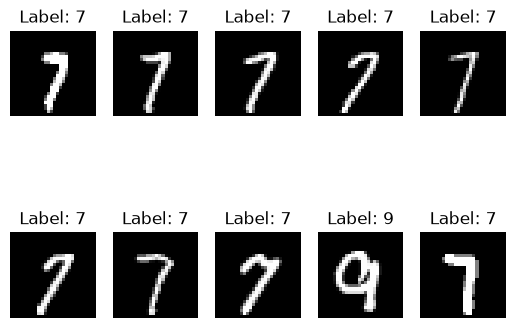

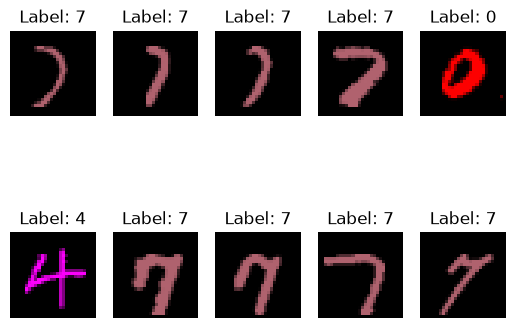

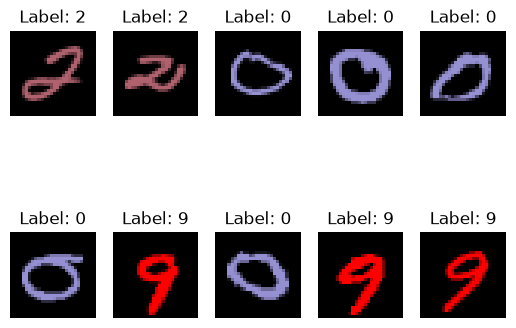

Neuron: 58


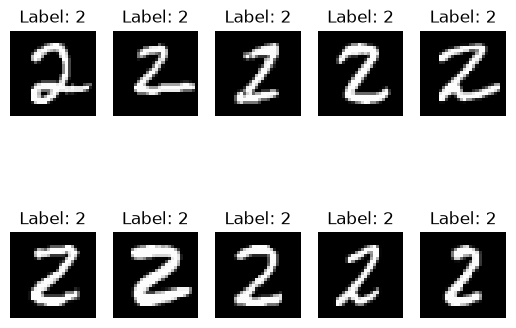

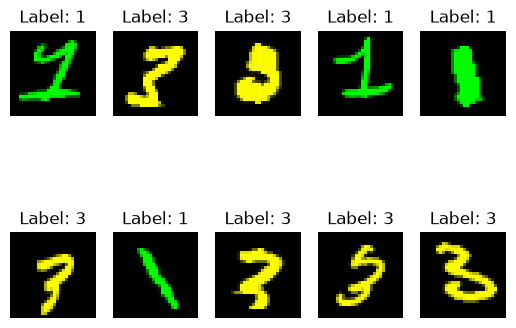

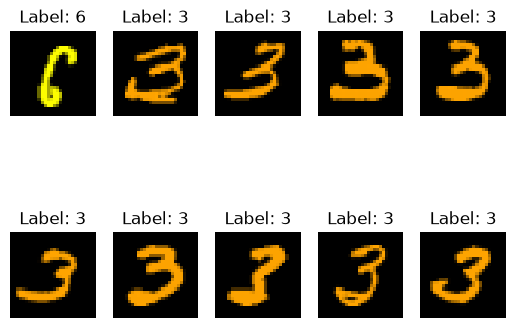

Neuron: 59


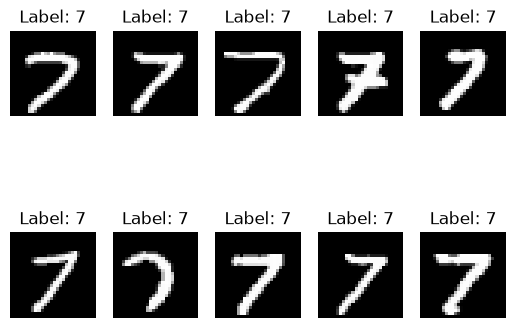

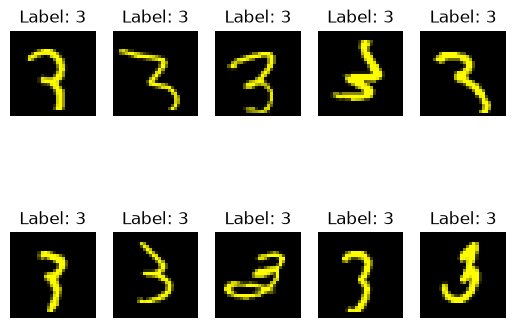

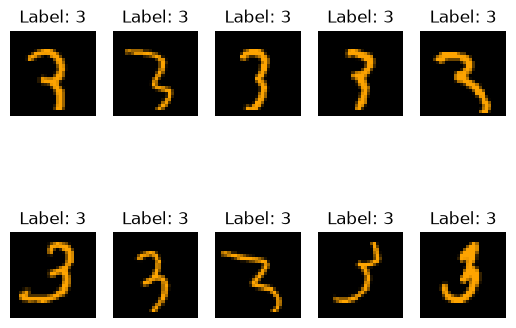

Neuron: 60


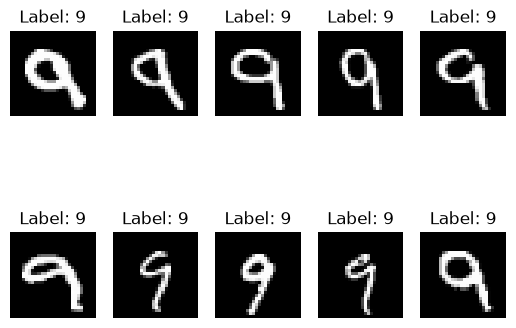

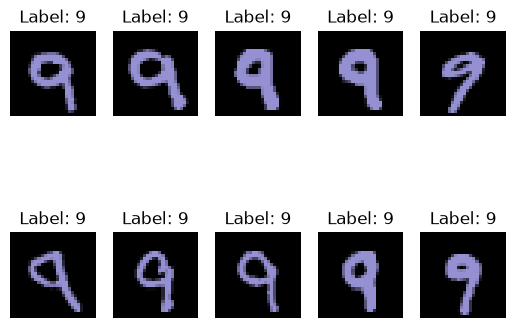

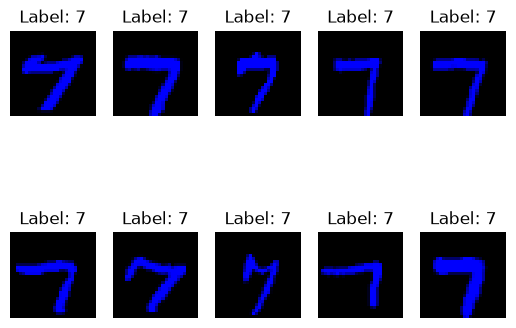

Neuron: 61


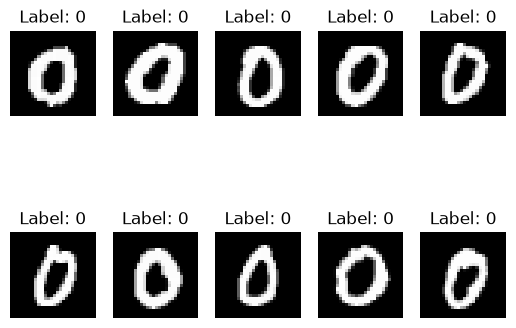

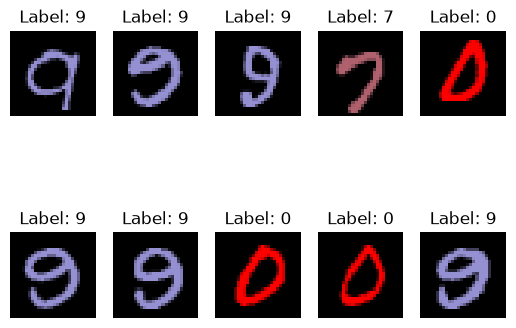

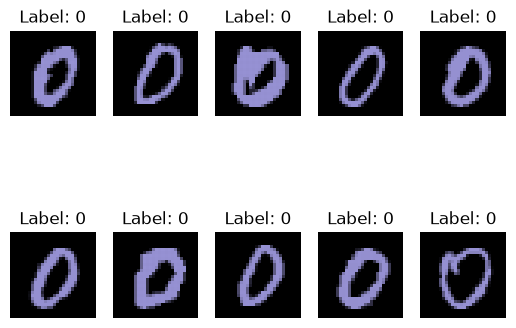

Neuron: 62


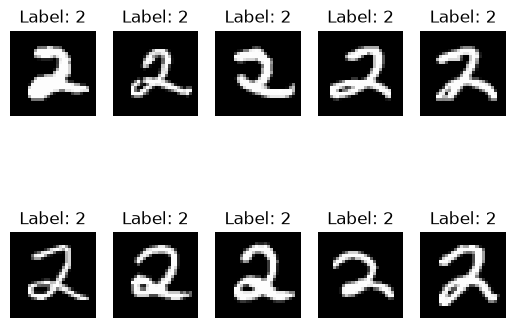

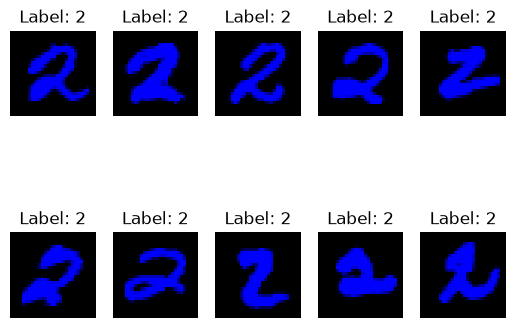

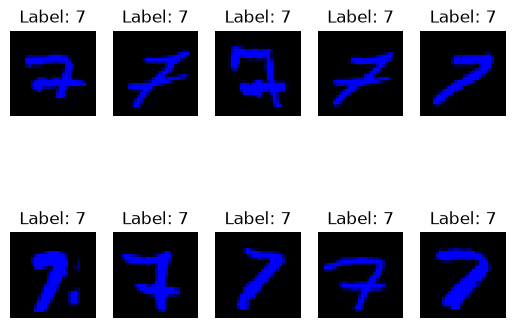

Neuron: 63


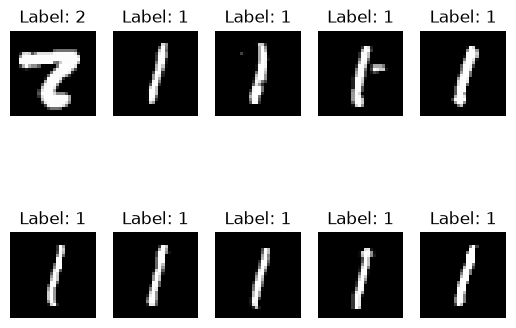

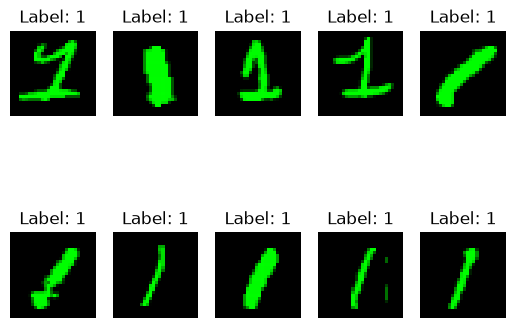

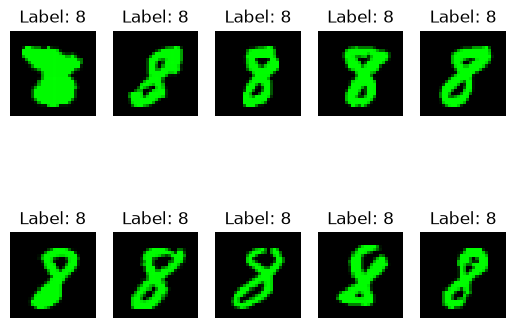

In [17]:
neurons_to_show = min(100, SAE_HIDDEN_DIM)
print(f"Showing representative samples for {neurons_to_show} out of {SAE_HIDDEN_DIM} sae neurons")

for neuron_idx in range(neurons_to_show):
    print(f"Neuron: {neuron_idx}")
    plot_utils.show_from_dataset(clean_val_dataset, clean_val_representatives[neuron_idx].tolist())
    plot_utils.show_from_dataset(fully_colored_val_dataset, fully_colored_val_representatives[neuron_idx].tolist())
    plot_utils.show_from_dataset(colors_flipped_val_dataset, colors_flipped_val_representatives[neuron_idx].tolist())

# Check representatives for features activating at specific dataset examples

Label: 7


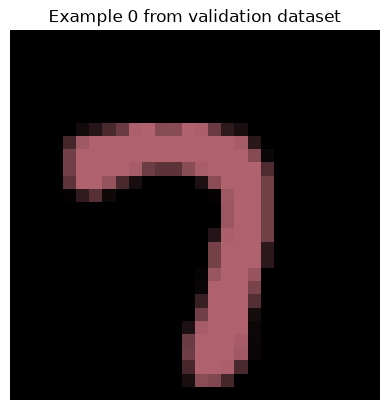

TOP 2 features for example 0: [10, 59]

Representative samples for feature 10:
Values: [3.5265185832977295, 3.5239646434783936, 3.5237183570861816, 3.5213849544525146, 3.5141537189483643, 3.512197732925415, 3.509596824645996, 3.5064682960510254, 3.4958324432373047, 3.4947962760925293]


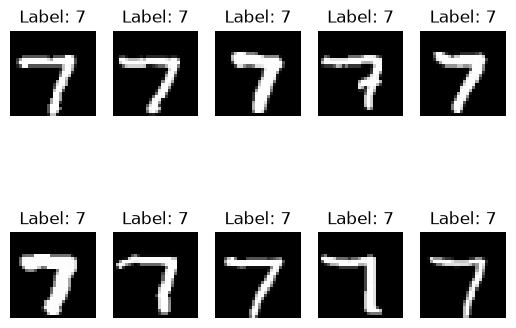

Values: [3.5222575664520264, 3.5152134895324707, 3.513859987258911, 3.5122599601745605, 3.5119409561157227, 3.510904312133789, 3.5083727836608887, 3.5071768760681152, 3.5065650939941406, 3.501601457595825]


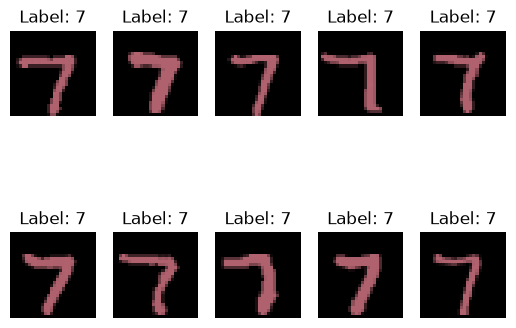

Values: [3.250382423400879, 3.1422181129455566, 2.9714574813842773, 2.8949637413024902, 2.828481912612915, 2.7485954761505127, 2.5598232746124268, 2.485196352005005, 2.478867292404175, 2.4276275634765625]


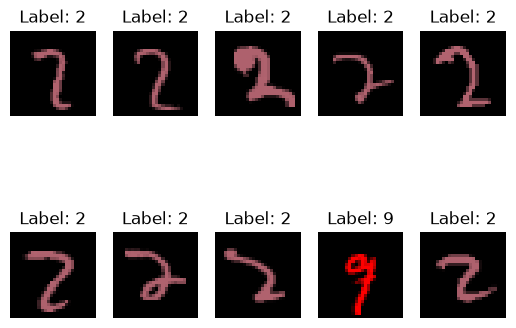


Representative samples for feature 59:
Values: [1.1770490407943726, 1.157884120941162, 1.152787685394287, 1.1434000730514526, 1.1342653036117554, 1.1310758590698242, 1.128950834274292, 1.1279330253601074, 1.125308871269226, 1.1155059337615967]


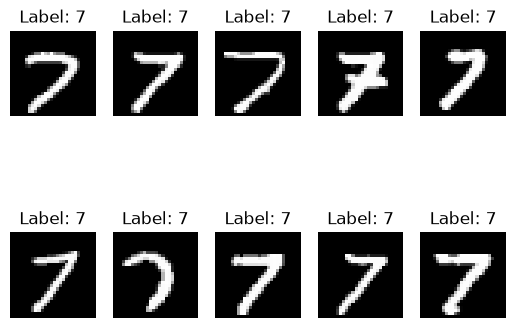

Values: [2.622520685195923, 2.622514009475708, 2.614593982696533, 2.610960006713867, 2.5787856578826904, 2.5767810344696045, 2.5754716396331787, 2.566253900527954, 2.5640499591827393, 2.559206962585449]


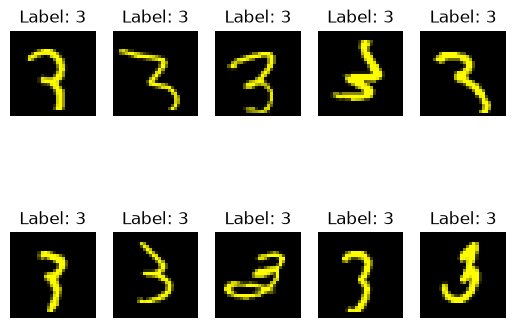

Values: [2.646742820739746, 2.6273434162139893, 2.6248669624328613, 2.623323678970337, 2.6105093955993652, 2.587719202041626, 2.5833210945129395, 2.578744411468506, 2.56650972366333, 2.565009832382202]


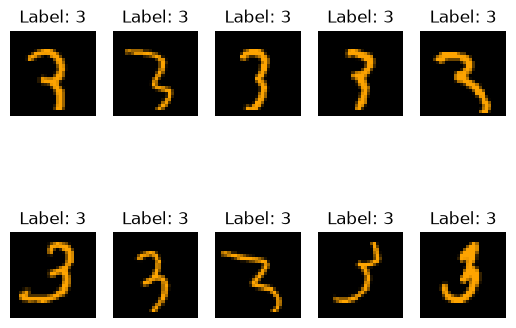

In [18]:
example_idx = 0
top_k = SAE_TOPK
experiment_dataset = fully_colored_val_dataset  # Change this to colors_flipped_val_dataset to test on the colors flipped dataset

print(f"Label: {experiment_dataset[example_idx][1]}")

inputs = experiment_dataset[example_idx][0].unsqueeze(0).to(device)
sae_input = model.fc[:SAE_FEATURES_LAYER+1](inputs)

sae_output, sae_hidden = sae_model(sae_input)
topk_features = torch.topk(sae_hidden, top_k).indices.squeeze().tolist()

plt.imshow(inputs.squeeze().cpu().permute(1, 2, 0))
plt.axis('off')
plt.title(f"Example {example_idx} from validation dataset")
plt.show()

print(f"TOP {top_k} features for example {example_idx}: {topk_features}")

for i in range(top_k):
    print("\n==============")
    print(f"Representative samples for feature {topk_features[i]}:")
    print(f"Values: {clean_val_top_values[topk_features[i]].tolist()}")
    plot_utils.show_from_dataset(clean_val_dataset, clean_val_representatives[topk_features[i]].tolist())
    print(f"Values: {fully_colored_val_top_values[topk_features[i]].tolist()}")
    plot_utils.show_from_dataset(fully_colored_val_dataset, fully_colored_val_representatives[topk_features[i]].tolist())
    print(f"Values: {colors_flipped_val_top_values[topk_features[i]].tolist()}")
    plot_utils.show_from_dataset(colors_flipped_val_dataset, colors_flipped_val_representatives[topk_features[i]].tolist())

In [19]:
checkpoint_path = os.path.join("weights", RUN_NAME, f"sae_model__topk_{SAE_TOPK}__hidden_{SAE_HIDDEN_DIM}__cp_{COLORED_PROPORTION}.pt")

if not os.path.exists(checkpoint_path):
	torch.save(sae_model.state_dict(), checkpoint_path)
else:
	raise ValueError(f"Checkpoint path {checkpoint_path} already exists. Please remove it or change the parameters to avoid overwriting.")

ValueError: Checkpoint path weights/cls_small_network/sae_model__topk_2__hidden_64__cp_0.95.pt already exists. Please remove it or change the parameters to avoid overwriting.

In [20]:
sae_model.load_state_dict(torch.load(checkpoint_path))

<All keys matched successfully>

# Validate model with SAE neurons killed that ativate for certain colors

In [60]:
class TrimmedClsModel(nn.Module):
    def __init__(
        self,
        cls_model: nn.Module,
        sae_model: nn.Module,
        neurons_to_kill: list = [],
        sae_features_layer: int = -3,
        steering_weights: float | List[float] = 0.5
    ):
        super().__init__()
        self.cls_model = cls_model
        self.cls_backbone = self.cls_model.fc[: sae_features_layer + 1]
        self.cls_head = self.cls_model.fc[sae_features_layer + 1 :]

        self.sae_model = sae_model
        self.neurons_to_kill = torch.tensor(neurons_to_kill, device=device, dtype=torch.long)

        selected_neurons_weights = torch.tensor(steering_weights, device=device, dtype=torch.float32)    # Scaling value for steering
        selected_neurons_weights = selected_neurons_weights.unsqueeze(-1).broadcast_to((len(self.neurons_to_kill), 1))

        sae_hidden_dim = self.sae_model.hidden_dim

        self.steering_weights = torch.zeros((sae_hidden_dim, 1), device=device)
        self.steering_weights[self.neurons_to_kill] = selected_neurons_weights

        self.steering_matrix = self.sae_model.weights.T
        self.steering_matrix = self.steering_matrix * self.steering_weights

    def forward(self, x, return_topk_indices=False):
        # Embedding extraction using cls backbone
        embedding = self.cls_backbone(x)

        # SAE embedding modification
        init_hidden = self.sae_model.encode(embedding)  # SAE hidden before steering
        # modified_hidden[:, self.neurons_to_kill] = 0

        topk = getattr(self.sae_model, "topk", 0)

        if topk:
            init_values, init_indices = torch.topk(init_hidden, topk, dim=1)
            modification_vector = self.steering_matrix[init_indices]

            modification_vector = modification_vector.sum(axis=1)   # Sum modifications for all neurons in topk and neurons_to_kill
            modified_embedding = embedding - modification_vector

            post_hidden = self.sae_model.encode(modified_embedding)
            post_values, post_indices = torch.topk(post_hidden, topk, dim=1)
            # sparse_hidden = torch.zeros_like(modified_hidden)
            # sparse_hidden.scatter_(1, indices, values)

        # sae_output = self.sae_model.decode(modified_hidden)

        cls_output = self.cls_head(modified_embedding)
        if return_topk_indices:
            return cls_output, init_indices, post_indices
        return cls_output


In [200]:
neurons_to_kill = [8, 9, 10, 13, 14, 33, 51, 56, 57, 62]
# steering_weights = [0, 2, 2, 0, 2, 2, 2, 2, 2, 0]
steering_weights = [0, -3, -2, 0, -3, -5, -20, -10, -4, 0]

steering_weights = torch.tensor(steering_weights, device=device, dtype=torch.float32) * 0.25

In [201]:
trimmed_model = TrimmedClsModel(model, sae_model, neurons_to_kill, sae_features_layer=SAE_FEATURES_LAYER, steering_weights=steering_weights)

cls_criterion = nn.CrossEntropyLoss()

/var/folders/v5/86dpvh4128n629_z9f0gzqt40000gn/T/ipykernel_72756/4282775100.py:18: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  selected_neurons_weights = torch.tensor(steering_weights, device=device, dtype=torch.float32)    # Scaling value for steering


In [202]:
metrics_calculator = metrics.MetricsCalculator(num_classes=10, average=None)

In [203]:
print("=========== BASELINE ===========")
# Evaluate the model on clean validation dataset
clean_val_loss = train_utils.cls_evaluate(model, clean_val_dataloader, cls_criterion, metrics_calculator, device)
clean_val_accuracy, clean_val_precision, clean_val_recall, clean_val_f1_score, clean_val_auprc, clean_val_auroc = metrics_calculator.compute_all()

# Evaluate the model on fully colored validation dataset
fully_colored_val_loss = train_utils.cls_evaluate(model, fully_colored_val_dataloader, cls_criterion, metrics_calculator, device)
fully_colored_val_accuracy, fully_colored_val_precision, fully_colored_val_recall, fully_colored_val_f1_score, fully_colored_val_auprc, fully_colored_val_auroc = metrics_calculator.compute_all()

colors_flipped_val_loss = train_utils.cls_evaluate(model, colors_flipped_val_dataloader, cls_criterion, metrics_calculator, device)
colors_flipped_val_accuracy, colors_flipped_val_precision, colors_flipped_val_recall, colors_flipped_val_f1_score, colors_flipped_val_auprc, colors_flipped_val_auroc = metrics_calculator.compute_all()

print("Performance on clean validation set:")
print(f"Clean Val Loss: {clean_val_loss}, Accuracy: {clean_val_accuracy}, Precision: {clean_val_precision}, Recall: {clean_val_recall}, F1 Score: {clean_val_f1_score}, AUPRC: {clean_val_auprc}, AUROC: {clean_val_auroc}")
print("Performance on fully colored validation set:")
print(f"Fully Colored Val Loss: {fully_colored_val_loss}, Accuracy: {fully_colored_val_accuracy}, Precision: {fully_colored_val_precision}, Recall: {fully_colored_val_recall}, F1 Score: {fully_colored_val_f1_score}, AUPRC: {fully_colored_val_auprc}, AUROC: {fully_colored_val_auroc}")
print("Performance on validation set with colors flipped:")
print(f"Colors flipped Val Loss: {colors_flipped_val_loss}, Accuracy: {colors_flipped_val_accuracy}, Precision: {colors_flipped_val_precision}, Recall: {colors_flipped_val_recall}, F1 Score: {colors_flipped_val_f1_score}, AUPRC: {colors_flipped_val_auprc}, AUROC: {colors_flipped_val_auroc}")

print("=========== TRIMMED ===========")
# Evaluate the model on clean validation dataset
clean_val_loss = train_utils.cls_evaluate(trimmed_model, clean_val_dataloader, cls_criterion, metrics_calculator, device)
clean_val_accuracy, clean_val_precision, clean_val_recall, clean_val_f1_score, clean_val_auprc, clean_val_auroc = metrics_calculator.compute_all()

# Evaluate the model on fully colored validation dataset
fully_colored_val_loss = train_utils.cls_evaluate(trimmed_model, fully_colored_val_dataloader, cls_criterion, metrics_calculator, device)
fully_colored_val_accuracy, fully_colored_val_precision, fully_colored_val_recall, fully_colored_val_f1_score, fully_colored_val_auprc, fully_colored_val_auroc = metrics_calculator.compute_all()

colors_flipped_val_loss = train_utils.cls_evaluate(trimmed_model, colors_flipped_val_dataloader, cls_criterion, metrics_calculator, device)
colors_flipped_val_accuracy, colors_flipped_val_precision, colors_flipped_val_recall, colors_flipped_val_f1_score, colors_flipped_val_auprc, colors_flipped_val_auroc = metrics_calculator.compute_all()

print("Performance on clean validation set:")
print(f"Clean Val Loss: {clean_val_loss}, Accuracy: {clean_val_accuracy}, Precision: {clean_val_precision}, Recall: {clean_val_recall}, F1 Score: {clean_val_f1_score}, AUPRC: {clean_val_auprc}, AUROC: {clean_val_auroc}")
print("Performance on fully colored validation set:")
print(f"Fully Colored Val Loss: {fully_colored_val_loss}, Accuracy: {fully_colored_val_accuracy}, Precision: {fully_colored_val_precision}, Recall: {fully_colored_val_recall}, F1 Score: {fully_colored_val_f1_score}, AUPRC: {fully_colored_val_auprc}, AUROC: {fully_colored_val_auroc}")
print("Performance on validation set with colors flipped:")
print(f"Colors flipped Val Loss: {colors_flipped_val_loss}, Accuracy: {colors_flipped_val_accuracy}, Precision: {colors_flipped_val_precision}, Recall: {colors_flipped_val_recall}, F1 Score: {colors_flipped_val_f1_score}, AUPRC: {colors_flipped_val_auprc}, AUROC: {colors_flipped_val_auroc}")


=========== BASELINE ===========


Evaluating: 100%|██████████| 375/375 [00:01<00:00, 345.20it/s]


Performance on clean validation set:
Clean Val Loss: 0.014600206649318959, Accuracy: tensor([0.9679, 0.9355, 0.8003, 0.7700, 0.8313, 0.8100, 0.9130, 0.9210, 0.8530,
        0.8958]), Precision: tensor([0.9679, 0.9355, 0.8003, 0.7700, 0.8313, 0.8100, 0.9130, 0.9210, 0.8530,
        0.8958]), Recall: tensor([0.9679, 0.9355, 0.8003, 0.7700, 0.8313, 0.8100, 0.9130, 0.9210, 0.8530,
        0.8958]), F1 Score: tensor([0.9265, 0.9446, 0.8591, 0.8321, 0.8767, 0.7946, 0.9031, 0.9228, 0.7978,
        0.8387]), AUPRC: tensor([0.9820, 0.9836, 0.8997, 0.9079, 0.9415, 0.8245, 0.9602, 0.9572, 0.8229,
        0.8818]), AUROC: tensor([0.9959, 0.9959, 0.9678, 0.9756, 0.9844, 0.9608, 0.9920, 0.9896, 0.9529,
        0.9789])
Performance on fully colored validation set:
Fully Colored Val Loss: 0.00013471145794089048, Accuracy: tensor([0.9992, 1.0000, 1.0000, 0.9959, 0.9991, 1.0000, 0.9992, 0.9992, 0.9983,
        0.9966]), Precision: tensor([0.9992, 1.0000, 1.0000, 0.9959, 0.9991, 1.0000, 0.9992, 0.9992, 0

Evaluating: 100%|██████████| 375/375 [00:01<00:00, 318.67it/s]

Performance on clean validation set:
Clean Val Loss: 0.014897299991299708, Accuracy: tensor([0.9679, 0.9355, 0.8037, 0.7724, 0.8305, 0.8090, 0.9122, 0.9282, 0.8513,
        0.8714]), Precision: tensor([0.9679, 0.9355, 0.8037, 0.7724, 0.8305, 0.8090, 0.9122, 0.9282, 0.8513,
        0.8714]), Recall: tensor([0.9679, 0.9355, 0.8037, 0.7724, 0.8305, 0.8090, 0.9122, 0.9282, 0.8513,
        0.8714]), F1 Score: tensor([0.9250, 0.9446, 0.8604, 0.8325, 0.8770, 0.7944, 0.9030, 0.9165, 0.7971,
        0.8299]), AUPRC: tensor([0.9815, 0.9833, 0.8875, 0.7265, 0.9413, 0.8254, 0.9604, 0.9570, 0.8222,
        0.8813]), AUROC: tensor([0.9958, 0.9952, 0.9654, 0.9646, 0.9843, 0.9616, 0.9920, 0.9900, 0.9527,
        0.9789])
Performance on fully colored validation set:
Fully Colored Val Loss: 0.00013832427333909436, Accuracy: tensor([0.9992, 1.0000, 1.0000, 0.9959, 0.9991, 1.0000, 0.9992, 0.9992, 0.9983,
        0.9950]), Precision: tensor([0.9992, 1.0000, 1.0000, 0.9959, 0.9991, 1.0000, 0.9992, 0.9992, 0

Label: 2
Output tensor(2, device='mps:0')
Init idx: tensor([[62, 25]], device='mps:0')
Post idx: tensor([[62, 25]], device='mps:0')


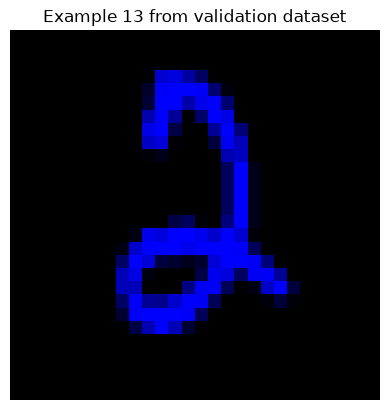

In [191]:
example_idx = 13
top_k = SAE_TOPK
experiment_dataset = fully_colored_val_dataset  # Change this to colors_flipped_val_dataset to test on the colors flipped dataset
neurons_to_kill = [8, 9, 10, 13, 14, 33, 51, 56, 57, 62]
# steering_weights = [0, 2, 2, 0, 2, 2, 2, 2, 2, 0]
steering_weights = [0, -3, -2, 0, -3, -5, -20, -10, -4, 0]

trimmed_model = TrimmedClsModel(model, sae_model, neurons_to_kill, sae_features_layer=SAE_FEATURES_LAYER, steering_weights=steering_weights)

print(f"Label: {experiment_dataset[example_idx][1]}")

inputs = experiment_dataset[example_idx][0].unsqueeze(0).to(device)
output, init_idx, post_idx = trimmed_model(inputs, return_topk_indices=True)

print("Output", torch.argmax(output))
print(f"Init idx: {init_idx}")
print(f"Post idx: {post_idx}")

plt.imshow(inputs.squeeze().cpu().permute(1, 2, 0))
plt.axis('off')
plt.title(f"Example {example_idx} from validation dataset")
plt.show()

# TODO
The problem is that representatives are created after topk. Because of that if a specific neuron is never in topk highest activating neuron then its representatives are always 0. This doesnt mean that it never activates after other neurons are killed in trimmed model. Thats why even after killing all neurons (those that at least once are in topk most activating) the model still keeps the accuracy high. It uses the rest of the neurons, that seems to never be activating but actually in case of killing other neurons ARE activating, just with smaller values. Probably they also activate on specific features.